In [34]:
import time
import os
import sys

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import Divider, Size
from matplotlib.ticker import MaxNLocator, MultipleLocator, FormatStrFormatter
import matplotlib.colors as mcolors
import smplotlib
width_plot_s = 3.46457
smplotlib.set_style(fontweight='normal', usetex=False, fontsize=9, figsize=(width_plot_s, width_plot_s), dpi=600)

dir = os.path.dirname(os.path.dirname('__file__'))+'/scripts/'
# print(dir)
sys.path.append('/Users/jmatthijsse/Documents/DVSI_project/DVSI_code/plotting/scripts')



import func as f
import vistools as vt
import plot
from polydust import Polydust, SizeDistribution

# Figure 1

Ndust: 1, tau:[0.001], Zmax:1Hg, Z:0.04, alpha:1.0e-05
Mdust: 0.09965147917075466, Mgas: 1.70600270599433 in domain
Dust-to-gas ratio in domain: 0.05841226325175938
Peak dust density: 0.3999951601753438
dz: 0.0009770395701025336

sigma gas: 0.8492569002123143
sigma vx: 0.22196015711460096
sigma vy: 0.8492569002123143 

sigma dust: 0.09915603280446661
sigma ux: 0.18794009565030692 

peak dvx/dz at z=0.24621397166585246 is 0.00014538612795015859
peak dvy/dz at z=0.12115290669272105 is 0.0818591444451712, and has a FWHM of 0.17000488519785048 or sigma of 0.07219442757699819
peak dax/dz at z=0.12115290669272105 is 0.16371922631272287
peak day/dz at z=0.0869565217391304 is 9.159898809609415e-05
peak dux/dz at z=0.2315583781143136 is 0.000197874966956959



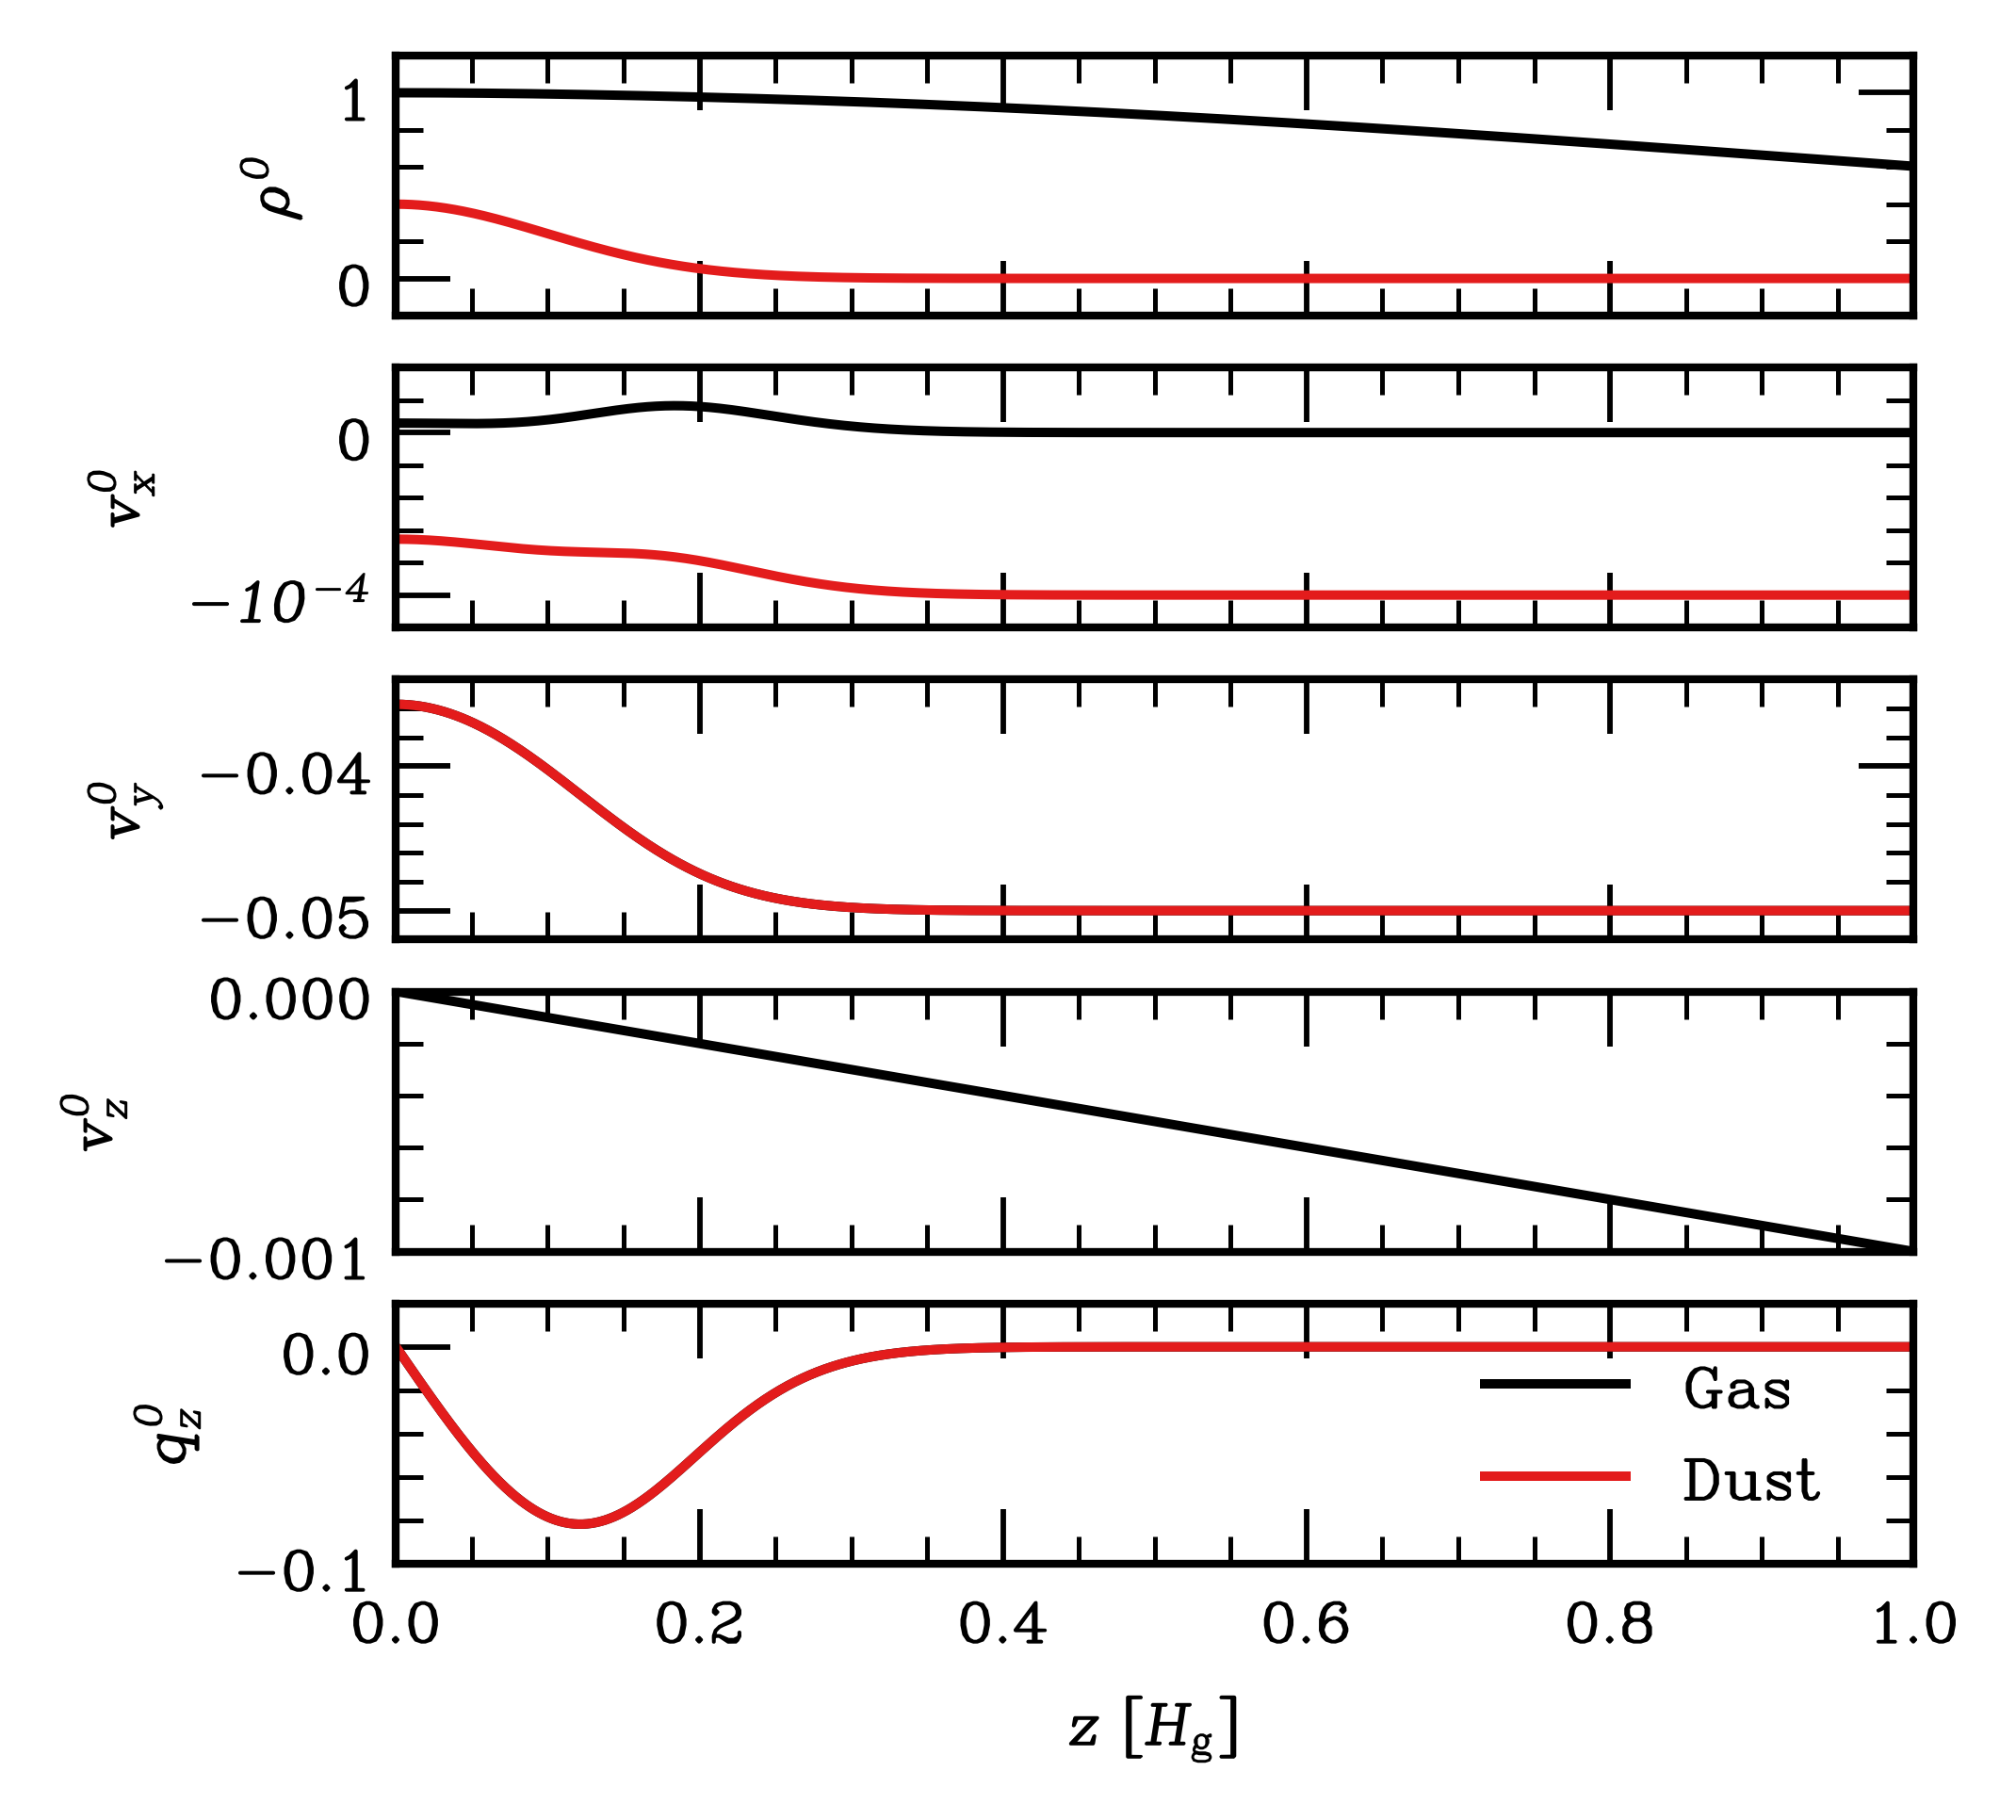

In [35]:
z, rhog, gas_vx, gas_vy, gas_vz, ax_gas, ay_gas, az_gas, dust_rho, dust_ux, dust_uy, dust_uz, sigma, dens_dust, stokes_numbers, weights = f.anytical(ndust=1, tau=[1e-3],  hg=1, metallicity=.04, eta=0.05, alpha_viscosity=1e-5)


fig, ax = plt.subplots(5,1, sharex=True)
domain = z>0
z_centre = (z[:-1]+z[1:])/2
domain_c = z_centre >0

ax[0].plot(z[domain], rhog[domain],label='Gas')
ax[0].plot(z[domain],dust_rho[domain],label='Dust')
ax[0].set_ylabel(r'$\rho^0$')
ax[0].set_ylim(-0.2, 1.2)

# ax[0].legend()

ax[1].plot(z[domain], gas_vx[domain])
ax[1].plot(z[domain], dust_ux[0,domain])
ax[1].set_ylabel(r'$v^0_x$')
ax[1].set_ylim(-0.00012,0.00004)
ax[1].set_yticks([-0.0001,0])

ax[1].set_yticklabels([r'$-10^{-4}$',0])


ax[2].plot(z[domain], gas_vy[domain])
ax[2].plot(z[domain], dust_uy[0,domain])
ax[2].set_ylabel(r'$v^0_y$')
ax[2].set_ylim(-0.052,-0.034)


ax[3].plot(z[domain], dust_uz[0,domain])
ax[3].set_ylabel(r'$v^0_z$')
ax[3].set_ylim(-0.001, 0)


gas_dvy_dz = np.diff(gas_vy)/np.diff(z)
dust_duy_dz = np.diff(dust_uy[0,:])/np.diff(z)

ax[4].plot(z_centre[domain_c], gas_dvy_dz[domain_c], label='Gas')
ax[4].plot(z_centre[domain_c], dust_duy_dz[domain_c], label='Dust')
ax[4].set_ylabel(r'$q^0_z$')
ax[4].set_ylim(-0.1, 0.02)
ax[4].legend(loc='center right')

pad = 3
for ax in ax:
    ax.xaxis.set_tick_params(pad=pad)
    ax.yaxis.set_tick_params(pad=pad)

plt.xlabel(r'$z \ [H_\mathrm{g}]$')

plt.xlim(0,1)

fig.savefig("plots/DVSI1_equilibrium.pdf",
            bbox_inches="tight", pad_inches=0.01, dpi=600)
plt.show()


# Figure 2

Ndust: 1, tau:[0.001], Zmax:4Hg, Z:0.05, alpha:1.0e-05
Mdust: 0.12452808059414364, Mgas: 0.9626196856654059 in domain
Dust-to-gas ratio in domain: 0.12936373777569724
Peak dust density: 0.49967177384793016
dz: 0.0071942446043165575

sigma gas: 0.42462845010615713
sigma vx: 0.2230063083291329
sigma vy: 0.42462845010615713 

sigma dust: 0.0947013090164811
sigma ux: 0.18634773709694666 

peak dvx/dz at z=-0.1366906474820144 is 0.0001709729569794117
peak dvy/dz at z=0.12949640287769787 is 0.09460016630211704, and has a FWHM of 0.1654676258992806 or sigma of 0.07026763095908073
peak dax/dz at z=0.12949640287769787 is 0.18920157258959514
peak day/dz at z=0.08633093525179857 is 0.00010614767981087759
peak dux/dz at z=0.23741007194244607 is 0.00022727378981888272



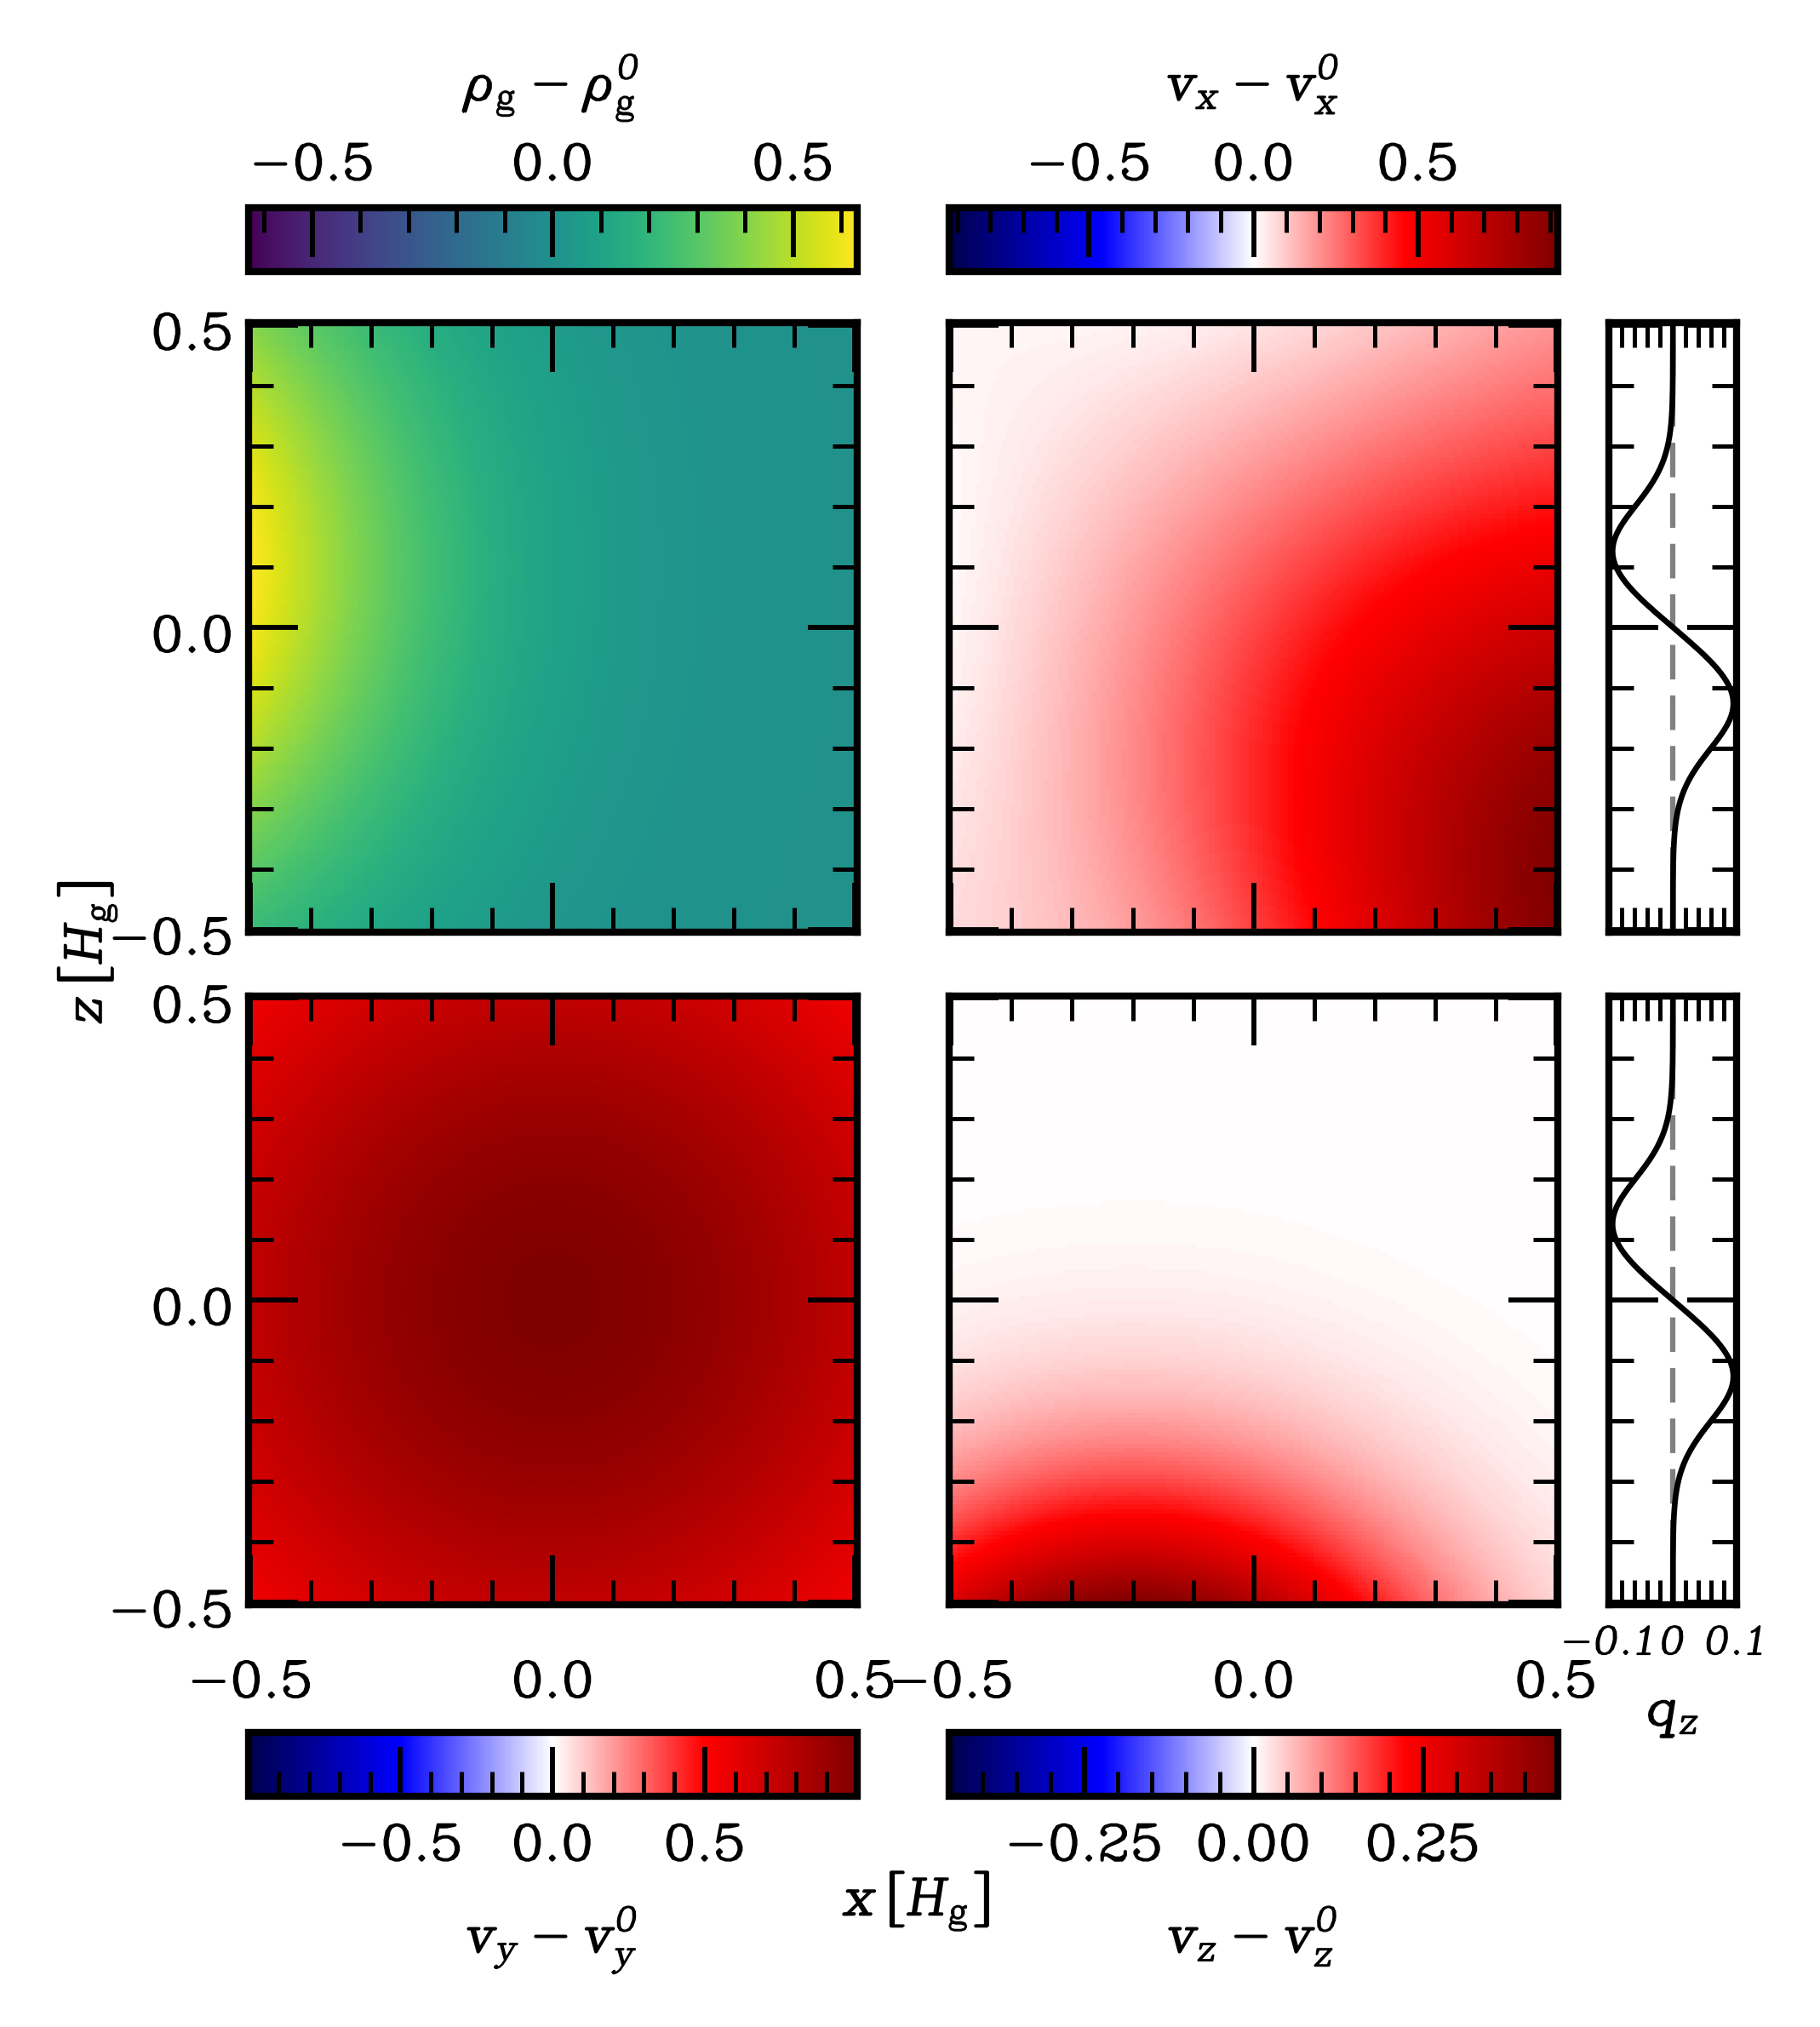

In [36]:
# run_name = 'DVSI_gas_2D_Z05_eta05_a5_tse3_hg4x5'
# folder = 'DVSI/'
# dir = f'/Volumes/datajmatthijsse/phd_project2/raw_data/{folder+run_name}/fargo3d/'
# # direc = f'/Users/jmatthijsse/Documents/PhD_project2/fargo3d/outputs/{run_name}/'
# df = pd.read_csv(f'/Volumes/datajmatthijsse/phd_project2/raw_data/DVSI/DVSI_gas_2D_Z5_eta05_a5_tse3_hg4x5/fargo3d/setups/DVSI_gas_2D_Z5_eta05_a5_tse3_hg4x5/initial.csv')
# # df = pd.read_csv(f'/Volumes/datajmatthijsse/phd_project2/raw_data/{folder+run_name}/fargo3d/setups/{run_name}/initial.csv')
# # df = pd.read_csv('/Users/jmatthijsse/Documents/PhD_project2/fargo3d/setups/'+run_name+'/initial.csv')
# t0 = [df['rho_g'][3:-3],df['vx_g'][3:-3], df['vy_g'][3:-3], df['vz_g'][3:-3]]

# frame=10

# # read in the data from the directories
# coord = vt.Coordinates(dir)
# pf = vt.PolyFluid(dir)
# dt = vt.time_stamps(dir, 2)[1]
# t = dt*frame
# frames = vt.time_stamps(dir, vt.max_save(dir))

# t0n = []
# for i in range(4):
#     if not isinstance(t0[i], (np.ndarray)):
#         t0n.append(t0[i]*np.ones_like(coord.z))
#     else:
#         t0n.appendt(t0[i])
# t0 = np.array(t0n)

# # Get Stokes numbers, dust densities and equilibrium velocities
# zmin = .5
# domain = (coord.z > -zmin) & (coord.z < zmin)
# coordx = coord.x
# coordz = coord.z[domain]
# meshX, meshZ = np.meshgrid(coordx, coordz, sparse=False, indexing='xy')
# keplershear = 1.5*meshX
# fluid = 0 
# pf.read(frame)
# rho = pf.Fluids[fluid].dens[domain,0,:]-t0[0][domain,None]
# velx= pf.Fluids[fluid].velx[domain,0,:]-t0[1][domain,None]
# vely = pf.Fluids[fluid].vely[domain,0,:]+keplershear-t0[2][domain,None]
# velz = pf.Fluids[fluid].velz[domain,0,:]-t0[3][domain,None]

# --- NEW EXAMPLE DATA (5 isotropic fields) ---
nx = nz = 140
zmin = 4
coordx = np.linspace(-.5, .5, nx)
coordz = np.linspace(-.5, .5, nz)
domain = (coordz > -zmin) & (coordz < zmin)
X, Z = np.meshgrid(coordx, coordz)

dens = [
    np.exp(-((X+0.9)**2 + (Z-0.1)**2) / 0.35),
    np.exp(-((X-0.7)**2 + (Z+0.4)**2) / 0.50) + 0.06*np.cos(4*X)*np.cos(4*Z),
    np.exp(-(X**2 + Z**2) / 0.85),
    np.exp(-((X+0.2)**2 + (Z+0.9)**2) / 0.20),
]
dens = [np.clip(d, 1e-9, None) for d in dens]  # keep positive if you switch on LogNorm later

# dens = [rho, velx, vely, velz]
fig, axes, cbs = plot.multi_heatmaps(
    dens, coordx, coordz,
    width_plot=width_plot_s,
    cbar_mode='per_panel',
    use_lognorm=False,
    symmetric=True,
    cbar_labels=[r"$\rho_\mathrm{g}-\rho^0_\mathrm{g}$", r"$v_x-v_x^0$", r"$v_y-v_y^0$", r"$v_z-v_z^0$"],
    cmap=["viridis", "seismic", "seismic", "seismic"],
    xlabel=r"$x \, [H_\mathrm{g}]$",
    ylabel=r"$z \, [H_\mathrm{g}]$",
    panel_text=None,
    gap_x=0.18,
    gap_y=0.125,
    left=0.4, right=0.5,
    bottom=0.15, top=0.05,
    cbar_h=0.125,
    xlabel_clearance=0.4,
    cbar_pad_top=0.1,
    cbar_pad_bottom=0.25,
)

# Fig 1 / analytical profile
tau = [1e-3]
alpha = 1e-5
Z = 0.05
eta = 0.05
zmin = .5

z, rhog, gas_vx, gas_vy, gas_vz, ax_gas, ay_gas, az_gas, dust_rho, dust_ux, dust_uy, dust_uz, sigma, rho, stokes, weights = \
    f.anytical(metallicity=Z, hg=4, tau=tau, eta=eta, alpha_viscosity=alpha, z=coordz)

q_z = np.gradient(gas_vy, z, edge_order=2)
qz_profile = np.asarray(q_z)

if qz_profile.shape == coordz.shape:
    qz_profile = qz_profile[domain]
elif qz_profile.shape != coordz.shape:
    raise ValueError(
        f"q_z has shape {qz_profile.shape}, but expected "
        f"{coordz.shape} or {coordz.shape}."
    )

# ------------------------------------------------------------
# Add side plots
# ------------------------------------------------------------
fig.canvas.draw()

finite_qz = qz_profile[np.isfinite(qz_profile)]
if finite_qz.size:
    qz_max = np.max(np.abs(finite_qz))
else:
    qz_max = None

qz_max = 0.1



ax_qz_top = plot.add_side_profile(
    fig, axes[1], qz_profile, coordz,
    profile_gap=0.1,
    profile_width=0.25,
    xlabel=r"$q_z$",
    show_xlabels=False
)

ax_qz_bottom = plot.add_side_profile(
    fig, axes[3], qz_profile, coordz,
    profile_gap=0.1,
    profile_width=0.25,
    xlabel=r"$q_z$",
    show_xlabels=True
)
# ax_qz_bottom[0,1].set_ytickslabels(['','0','0.1'])

pad = 2
for ax in axes:
    ax.xaxis.set_tick_params(pad=pad*3)
    ax.yaxis.set_tick_params(pad=pad)
for cb in cbs:
    cb.ax.xaxis.set_tick_params(pad=pad)
    cb.ax.yaxis.set_tick_params(pad=pad)

fig.savefig("plots/DVSI1_gas_t50_sidebar.pdf",
            bbox_inches="tight", pad_inches=0.01, dpi=600)
plt.show()

# Figure 3

Ndust: 1, tau:[0.001], Zmax:4Hg, Z:0.05, alpha:1.0e-05
Mdust: 0.1245281320243514, Mgas: 2.464705894312721 in domain
Dust-to-gas ratio in domain: 0.050524540194308194
Peak dust density: 0.4996755184005427
dz: 0.007153075822603938

sigma gas: 0.993229636514402
sigma vx: 0.2217301635032151
sigma vy: 2.1231422505307855 

sigma dust: 0.09415938450136517
sigma ux: 0.1852813695026866 

peak dvx/dz at z=-0.1359084406294706 is 0.00017076948928173018
peak dvy/dz at z=0.1287553648068669 is 0.09463974837393546, and has a FWHM of 0.16452074391988558 or sigma of 0.0698655272053807
peak dax/dz at z=0.1287553648068669 is 0.18928071601251617
peak day/dz at z=0.09298998569384831 is 0.00010620086669970752
peak dux/dz at z=0.23605150214592274 is 0.00022713827034316598



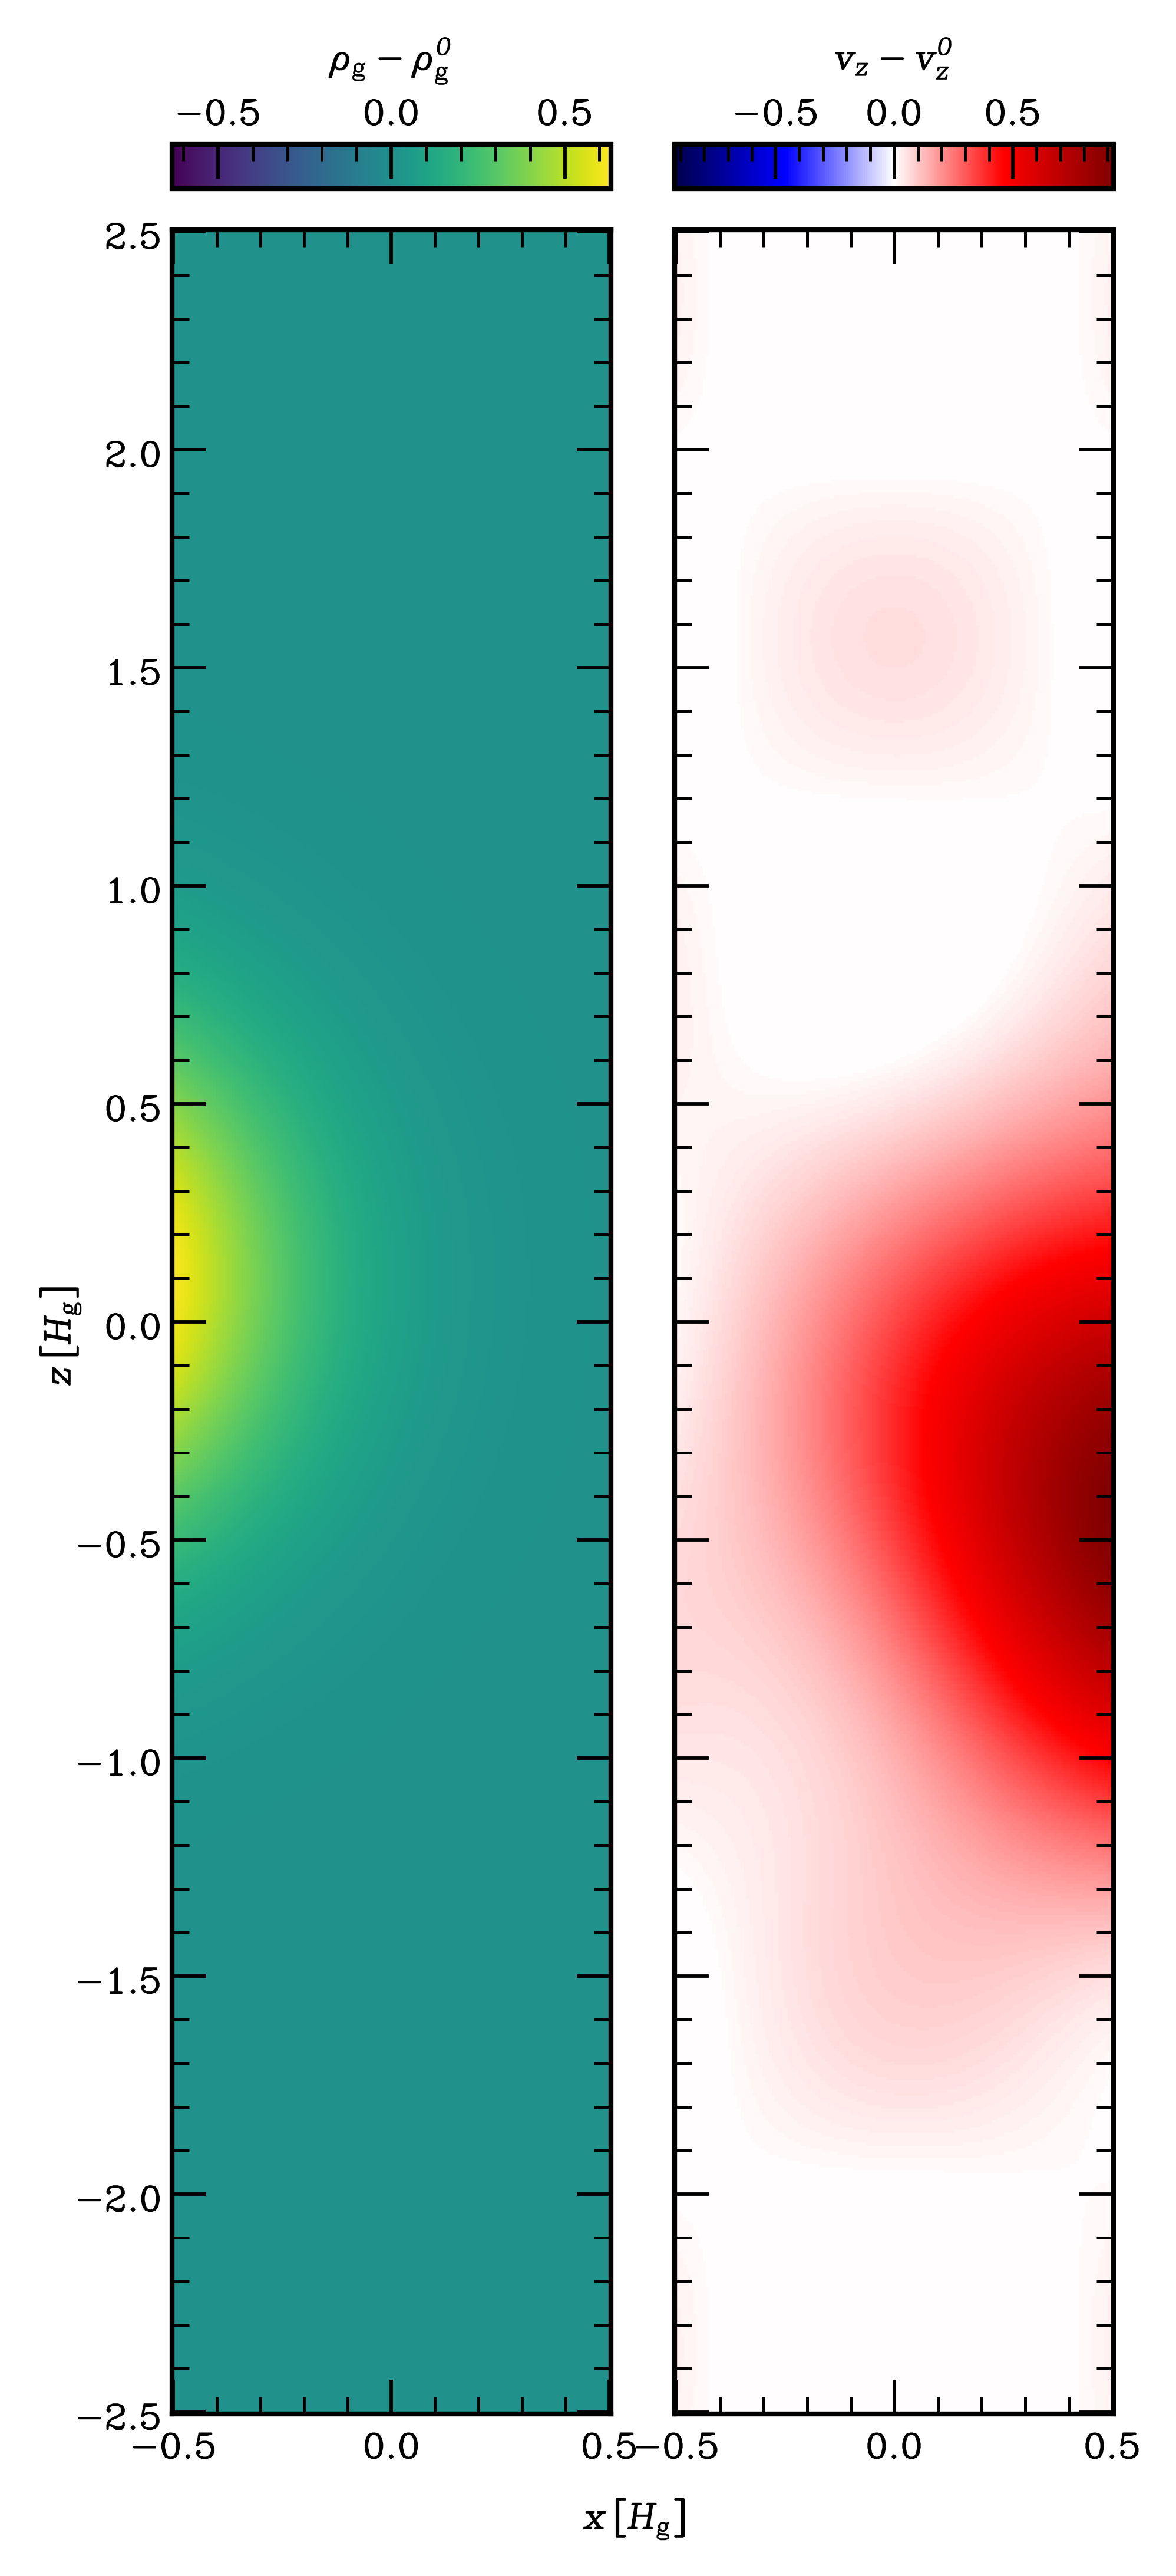

In [37]:
# run_name = 'DVSI_gas_2D_Z05_eta05_a5_tse3_hg4x5'
# folder = 'DVSI/'
# dir = f'/Volumes/datajmatthijsse/phd_project2/raw_data/{folder+run_name}/fargo3d/'
# # direc = f'/Users/jmatthijsse/Documents/PhD_project2/fargo3d/outputs/{run_name}/'
# df = pd.read_csv(f'/Volumes/datajmatthijsse/phd_project2/raw_data/DVSI/DVSI_gas_2D_Z5_eta05_a5_tse3_hg4x5/fargo3d/setups/DVSI_gas_2D_Z5_eta05_a5_tse3_hg4x5/initial.csv')
# # df = pd.read_csv(f'/Volumes/datajmatthijsse/phd_project2/raw_data/{folder+run_name}/fargo3d/setups/{run_name}/initial.csv')
# # df = pd.read_csv('/Users/jmatthijsse/Documents/PhD_project2/fargo3d/setups/'+run_name+'/initial.csv')
# t0 = [df['rho_g'][3:-3],df['vx_g'][3:-3], df['vy_g'][3:-3], df['vz_g'][3:-3]]

# frame=100

# # read in the data from the directories
# coord = vt.Coordinates(dir)
# pf = vt.PolyFluid(dir)
# dt = vt.time_stamps(dir, 2)[1]
# t = dt*frame
# frames = vt.time_stamps(dir, vt.max_save(dir))

# t0n = []
# for i in range(4):
#     if not isinstance(t0[i], (np.ndarray)):
#         t0n.append(t0[i]*np.ones_like(coord.z))
#     else:
#         t0n.appendt(t0[i])
# t0 = np.array(t0n)

# # Get Stokes numbers, dust densities and equilibrium velocities
# zmin = 2.5
# domain = (coord.z > -zmin) & (coord.z < zmin)
# coordx = coord.x
# coordz = coord.z[domain]
# meshX, meshZ = np.meshgrid(coordx, coordz, sparse=False, indexing='xy')
# keplershear = 1.5*meshX
# fluid = 0 
# pf.read(frame)
# rho = pf.Fluids[fluid].dens[domain,0,:]-t0[0][domain,None]
# velx= pf.Fluids[fluid].velx[domain,0,:]-t0[1][domain,None]
# vely = pf.Fluids[fluid].vely[domain,0,:]+keplershear-t0[2][domain,None]
# velz = pf.Fluids[fluid].velz[domain,0,:]-t0[3][domain,None]

# --- NEW EXAMPLE DATA (5 isotropic fields) ---
nx = 140
nz = nx*5
zmin = 4
coordx = np.linspace(-.5, .5, nx)
coordz = np.linspace(-2.5, 2.5, nz)
domain = (coordz > -zmin) & (coordz < zmin)
X, Z = np.meshgrid(coordx, coordz)

dens = [
    np.exp(-((X+0.9)**2 + (Z-0.1)**2) / 0.35),
    np.exp(-((X-0.7)**2 + (Z+0.4)**2) / 0.50) + 0.06*np.cos(4*X)*np.cos(4*Z),
    # np.exp(-(X**2 + Z**2) / 0.85),
    # np.exp(-((X+0.2)**2 + (Z+0.9)**2) / 0.20),
]
dens = [np.clip(d, 1e-9, None) for d in dens]  # keep positive if you switch on LogNorm later

# dens = [rho, velx, vely, velz]
fig, axes, cbs = plot.multi_heatmaps(
    dens, coordx, coordz,
    width_plot=width_plot_s,
    cbar_mode='per_panel',
    use_lognorm=False,
    symmetric=True,
    cbar_labels=[r"$\rho_\mathrm{g}-\rho^0_\mathrm{g}$", r"$v_z-v_z^0$"],
    cmap=["viridis", "seismic"],
    xlabel=r"$x \, [H_\mathrm{g}]$",
    ylabel=r"$z \, [H_\mathrm{g}]$",
    panel_text=None,
    gap_x=0.18,
    gap_y=0.125,
    left=0.4, right=0.4,
    bottom=0.5, top=-0.25,
    cbar_h=0.125,
    xlabel_clearance=0,
    cbar_pad_top=0.1,
)

# Fig 1 / analytical profile
tau = [1e-3]
alpha = 1e-5
Z = 0.05
eta = 0.05
zmin = .5

z, rhog, gas_vx, gas_vy, gas_vz, ax_gas, ay_gas, az_gas, dust_rho, dust_ux, dust_uy, dust_uz, sigma, rho, stokes, weights = \
    f.anytical(metallicity=Z, hg=4, tau=tau, eta=eta, alpha_viscosity=alpha, z=coordz)

q_z = np.gradient(gas_vy, z, edge_order=2)
qz_profile = np.asarray(q_z)

if qz_profile.shape == coordz.shape:
    qz_profile = qz_profile[domain]
elif qz_profile.shape != coordz.shape:
    raise ValueError(
        f"q_z has shape {qz_profile.shape}, but expected "
        f"{coordz.shape} or {coordz.shape}."
    )
pad = 2
for ax in axes:
    ax.xaxis.set_tick_params(pad=pad)
    ax.yaxis.set_tick_params(pad=pad)
for cb in cbs:
    cb.ax.xaxis.set_tick_params(pad=pad)
    cb.ax.yaxis.set_tick_params(pad=pad)

fig.savefig("plots/DVSI1_gas_t500.pdf",
            bbox_inches="tight", pad_inches=0.01, dpi=600)
plt.show()

# Figure 4

Ndust: 1, tau:[0.001], Zmax:4Hg, Z:0.05, alpha:1.0e-05
Mdust: 0.1245281320243482, Mgas: 2.164427026856869 in domain
Dust-to-gas ratio in domain: 0.05753399420685717
Peak dust density: 0.49967489877207744
dz: 0.007159904534606243

sigma gas: 0.9941778270981865
sigma vx: 0.2219418390769652
sigma vy: 1.2738853503184713 

sigma dust: 0.09424927412857427
sigma ux: 0.18545824909171066 

peak dvx/dz at z=-0.13603818615751795 is 0.00017080912231326814
peak dvy/dz at z=0.1288782816229117 is 0.09463380401803805, and has a FWHM of 0.1646778042959427 or sigma of 0.06993222460605407
peak dax/dz at z=0.1288782816229117 is 0.18926883078932819
peak day/dz at z=0.09307875894988071 is 0.00010619032081471954
peak dux/dz at z=0.2362768496420048 is 0.00022717219933126426



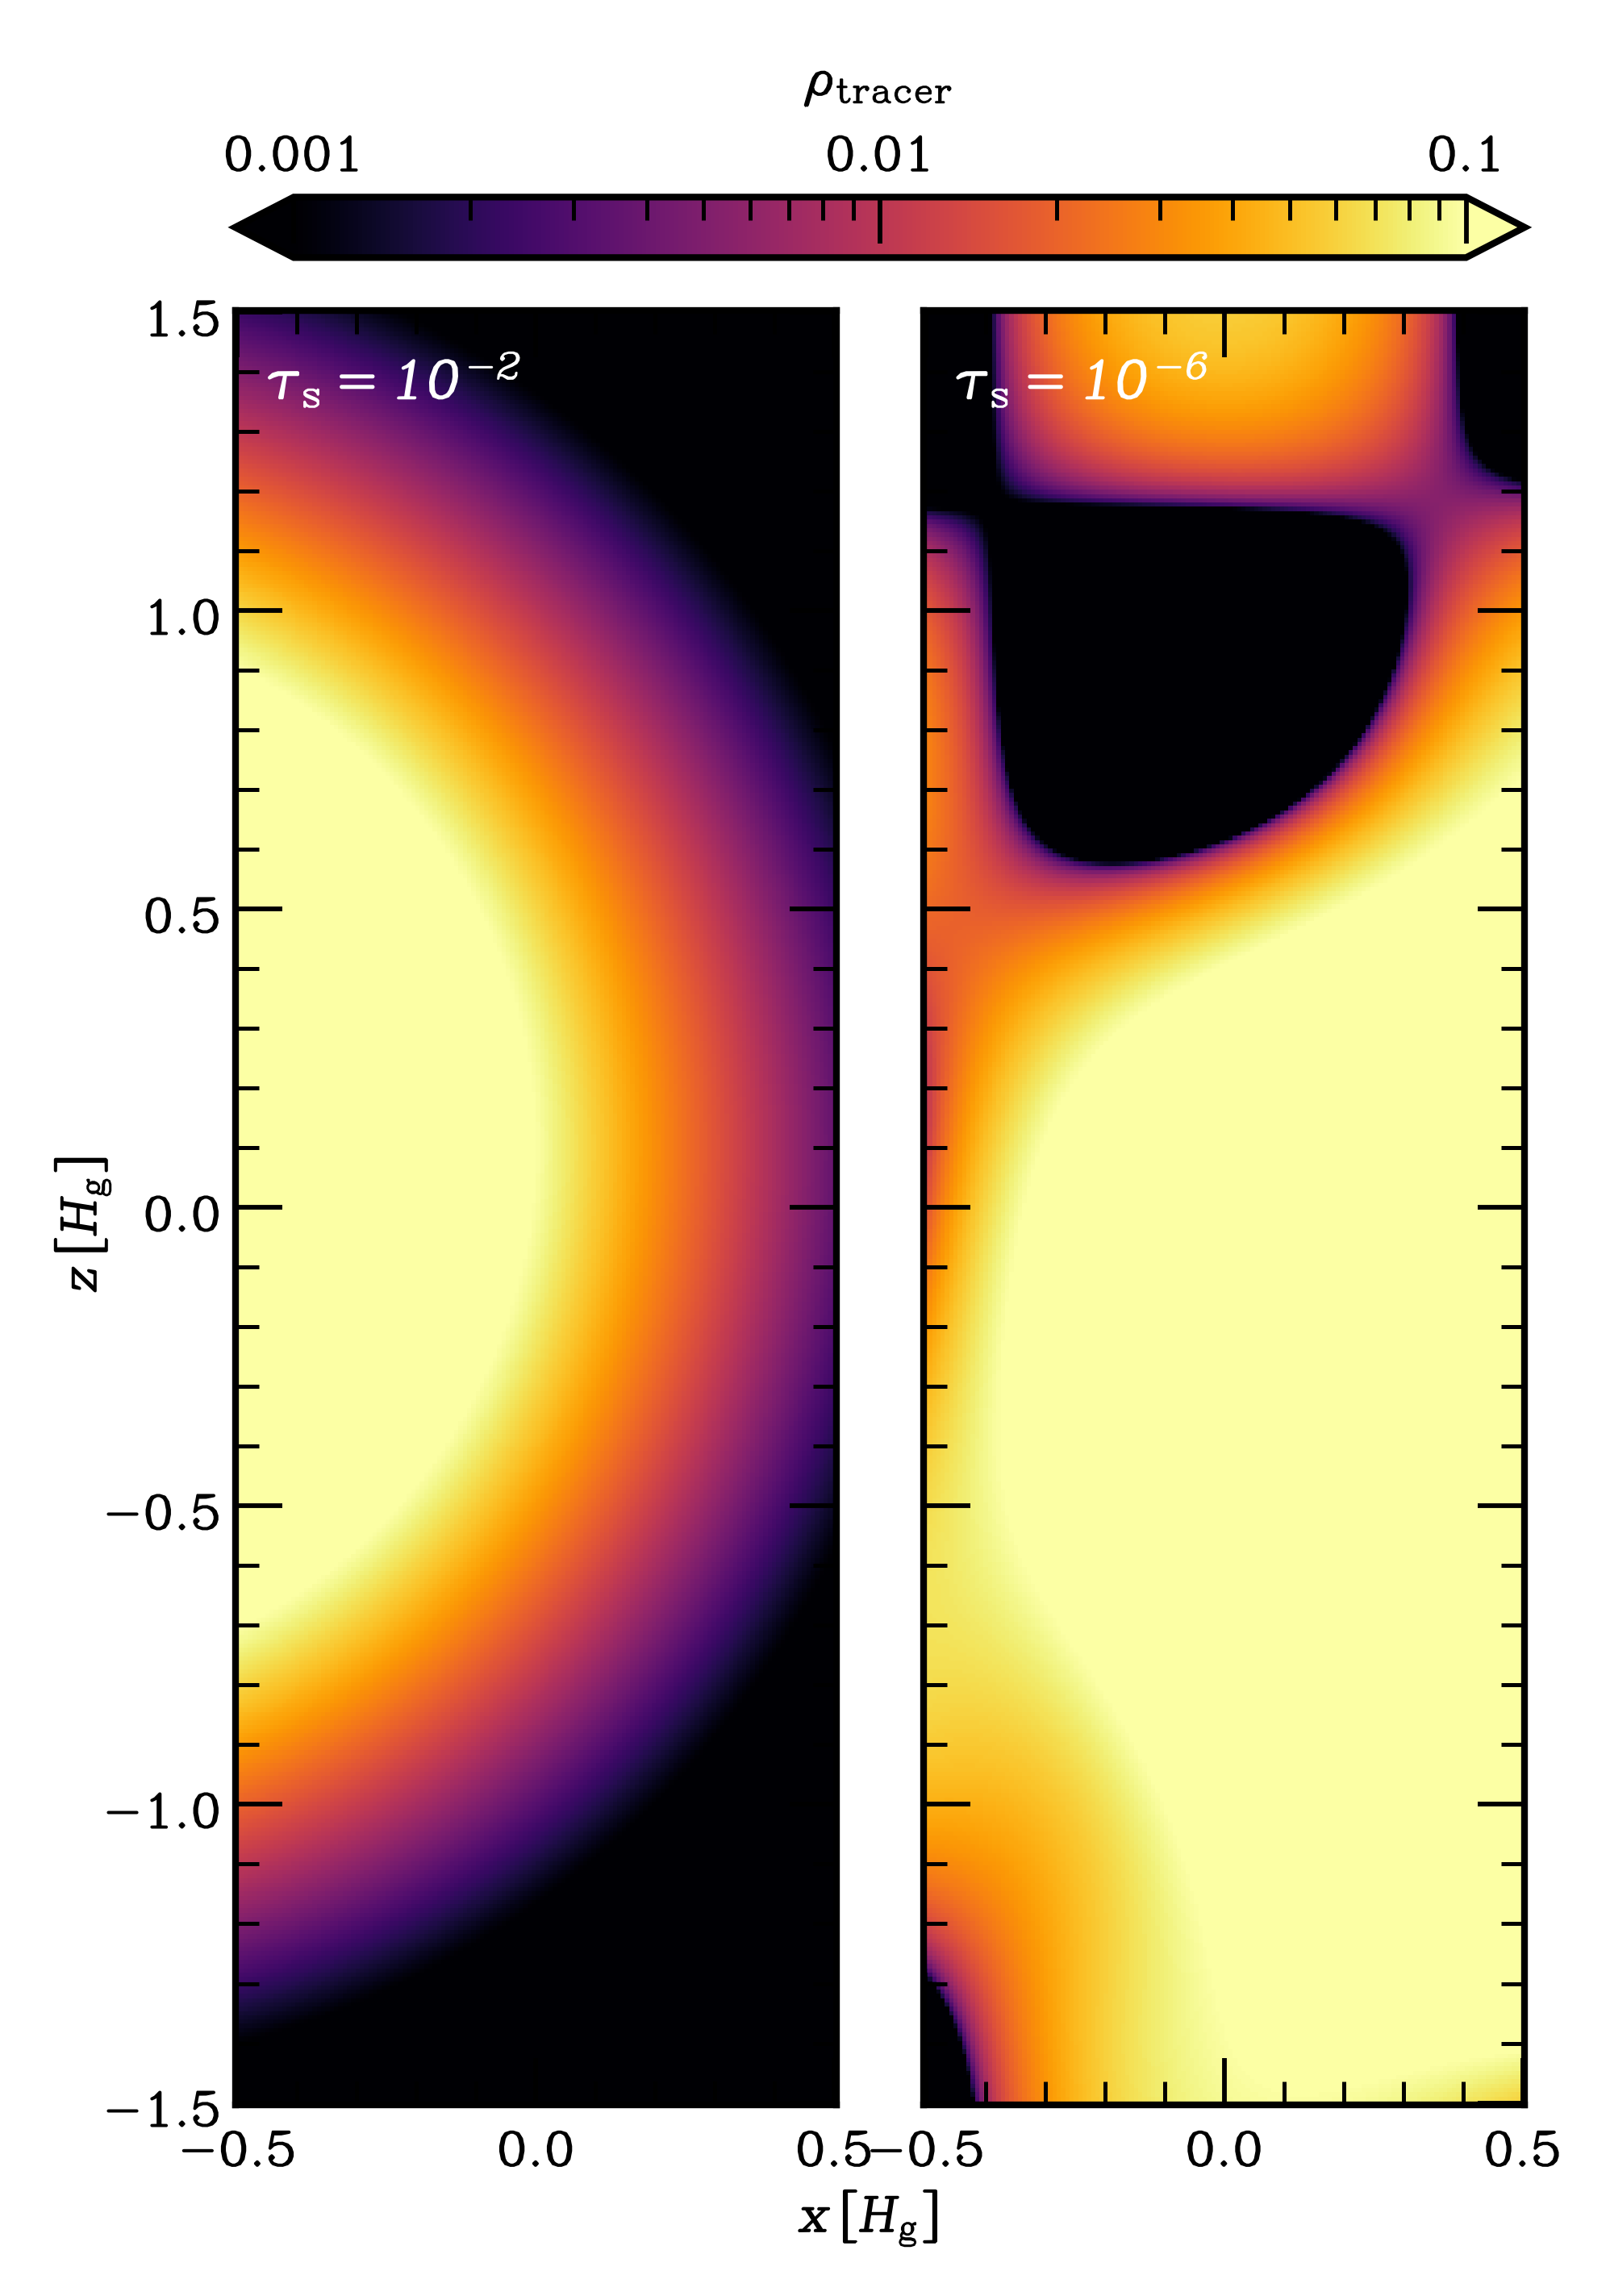

In [38]:
# run_name = 'DVSI_gas_2D_Z05_eta05_a5_tse3_hg4x5'
# folder = 'DVSI/'
# dir = f'/Volumes/datajmatthijsse/phd_project2/raw_data/{folder+run_name}/fargo3d/'
# # direc = f'/Users/jmatthijsse/Documents/PhD_project2/fargo3d/outputs/{run_name}/'
# df = pd.read_csv(f'/Volumes/datajmatthijsse/phd_project2/raw_data/DVSI/DVSI_gas_2D_Z5_eta05_a5_tse3_hg4x5/fargo3d/setups/DVSI_gas_2D_Z5_eta05_a5_tse3_hg4x5/initial.csv')
# # df = pd.read_csv(f'/Volumes/datajmatthijsse/phd_project2/raw_data/{folder+run_name}/fargo3d/setups/{run_name}/initial.csv')
# # df = pd.read_csv('/Users/jmatthijsse/Documents/PhD_project2/fargo3d/setups/'+run_name+'/initial.csv')
# t0 = [df['rho_g'][3:-3],df['vx_g'][3:-3], df['vy_g'][3:-3], df['vz_g'][3:-3]]

# frame=100

# # read in the data from the directories
# coord = vt.Coordinates(dir)
# pf = vt.PolyFluid(dir)
# dt = vt.time_stamps(dir, 2)[1]
# t = dt*frame
# frames = vt.time_stamps(dir, vt.max_save(dir))

# t0n = []
# for i in range(4):
#     if not isinstance(t0[i], (np.ndarray)):
#         t0n.append(t0[i]*np.ones_like(coord.z))
#     else:
#         t0n.appendt(t0[i])
# t0 = np.array(t0n)

# # Get Stokes numbers, dust densities and equilibrium velocities
# zmin = 1.5
# domain = (coord.z > -zmin) & (coord.z < zmin)
# coordx = coord.x
# coordz = coord.z[domain]
# meshX, meshZ = np.meshgrid(coordx, coordz, sparse=False, indexing='xy')
# keplershear = 1.5*meshX
# fluid = 2
# pf.read(frame)
# rho = pf.Fluids[fluid].dens[domain,0,:]-t0[0][domain,None]
fluid = 1
# rho = pf.Fluids[fluid].dens[domain,0,:]-t0[0][domain,None]
# vely = pf.Fluids[fluid].vely[domain,0,:]+keplershear-t0[2][domain,None]
# velz = pf.Fluids[fluid].velz[domain,0,:]-t0[3][domain,None]

# --- NEW EXAMPLE DATA (5 isotropic fields) ---
nx = 140
nz = nx*3
zmin = 4
coordx = np.linspace(-.5, .5, nx)
coordz = np.linspace(-1.5, 1.5, nz)
domain = (coordz > -zmin) & (coordz < zmin)
X, Z = np.meshgrid(coordx, coordz)

dens = [
    np.exp(-((X+0.9)**2 + (Z-0.1)**2) / 0.35),
    np.exp(-((X-0.7)**2 + (Z+0.4)**2) / 0.50) + 0.06*np.cos(4*X)*np.cos(4*Z),
    # np.exp(-(X**2 + Z**2) / 0.85),
    # np.exp(-((X+0.2)**2 + (Z+0.9)**2) / 0.20),
]
dens = [np.clip(d, 1e-9, None) for d in dens]  # keep positive if you switch on LogNorm later

# dens = [rho1, rho2]
fig, axes, cbs = plot.multi_heatmaps(
    dens, coordx, coordz,
    width_plot=width_plot_s,
    cbar_mode='shared',
    use_lognorm=True,
    symmetric=False,
    vmin_floor=1e-3,
    vmax=1e-1,
    cbar_labels=[r"$\rho_\mathrm{tracer}$"],
    cmap=["inferno"],
    xlabel=r"$x \, [H_\mathrm{g}]$",
    ylabel=r"$z \, [H_\mathrm{g}]$",
    panel_text=[r"$\ \tau_\mathrm{s}=10^{-2}$", r"$\ \tau_\mathrm{s}=10^{-6}$"],
    panel_text_kwargs=dict(
        fontsize=10,
        color="white",
        ha="left",
        va="top",
        transform=None,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.0, linewidth=0.0)
    ),
    gap_x=0.18,
    gap_y=0.125,
    left=0.4, right=0.4,
    bottom=0.4, top=-0.25,
    cbar_h=0.125,
    xlabel_clearance=0,
    cbar_pad_top=0.1,
)

# Fig 1 / analytical profile
tau = [1e-3]
alpha = 1e-5
Z = 0.05
eta = 0.05
zmin = .5

z, rhog, gas_vx, gas_vy, gas_vz, ax_gas, ay_gas, az_gas, dust_rho, dust_ux, dust_uy, dust_uz, sigma, rho, stokes, weights = \
    f.anytical(metallicity=Z, hg=4, tau=tau, eta=eta, alpha_viscosity=alpha, z=coordz)

q_z = np.gradient(gas_vy, z, edge_order=2)
qz_profile = np.asarray(q_z)

if qz_profile.shape == coordz.shape:
    qz_profile = qz_profile[domain]
elif qz_profile.shape != coordz.shape:
    raise ValueError(
        f"q_z has shape {qz_profile.shape}, but expected "
        f"{coordz.shape} or {coordz.shape}."
    )

pad = 2
for ax in axes:
    ax.xaxis.set_tick_params(pad=pad)
    ax.yaxis.set_tick_params(pad=pad)
for cb in cbs:
    cb.ax.xaxis.set_tick_params(pad=pad)
    cb.ax.yaxis.set_tick_params(pad=pad)

fig.savefig("plots/DVSI1_tracer_t500.pdf",
            bbox_inches="tight", pad_inches=0.01, dpi=600)
plt.show()

# Figure 5

750.0
0.0009765625
Ndust: 1, tau:[0.001], Zmax:4Hg, Z:0.05, alpha:1.0e-05
Mdust: 0.12452813202434755, Mgas: 2.495211506193665 in domain
Dust-to-gas ratio in domain: 0.04990684425558366
Peak dust density: 0.4999939501653337
dz: 0.0009765625

sigma gas: 0.9956376061571125
sigma vx: 0.22682789278131635
sigma vy: 3.39661292462845 

sigma dust: 0.09910761677282379
sigma ux: 0.18950703290870488 

peak dvx/dz at z=-0.138671875 is 0.00017141527720734677
peak dvy/dz at z=0.1259765625 is 0.09474097125767855, and has a FWHM of 0.1708984375 or sigma of 0.07257388430195476
peak dax/dz at z=0.1259765625 is 0.1894830800478644
peak day/dz at z=0.08984375 is 0.00010645887506548733
peak dux/dz at z=0.23828125 is 0.00022746171889261035



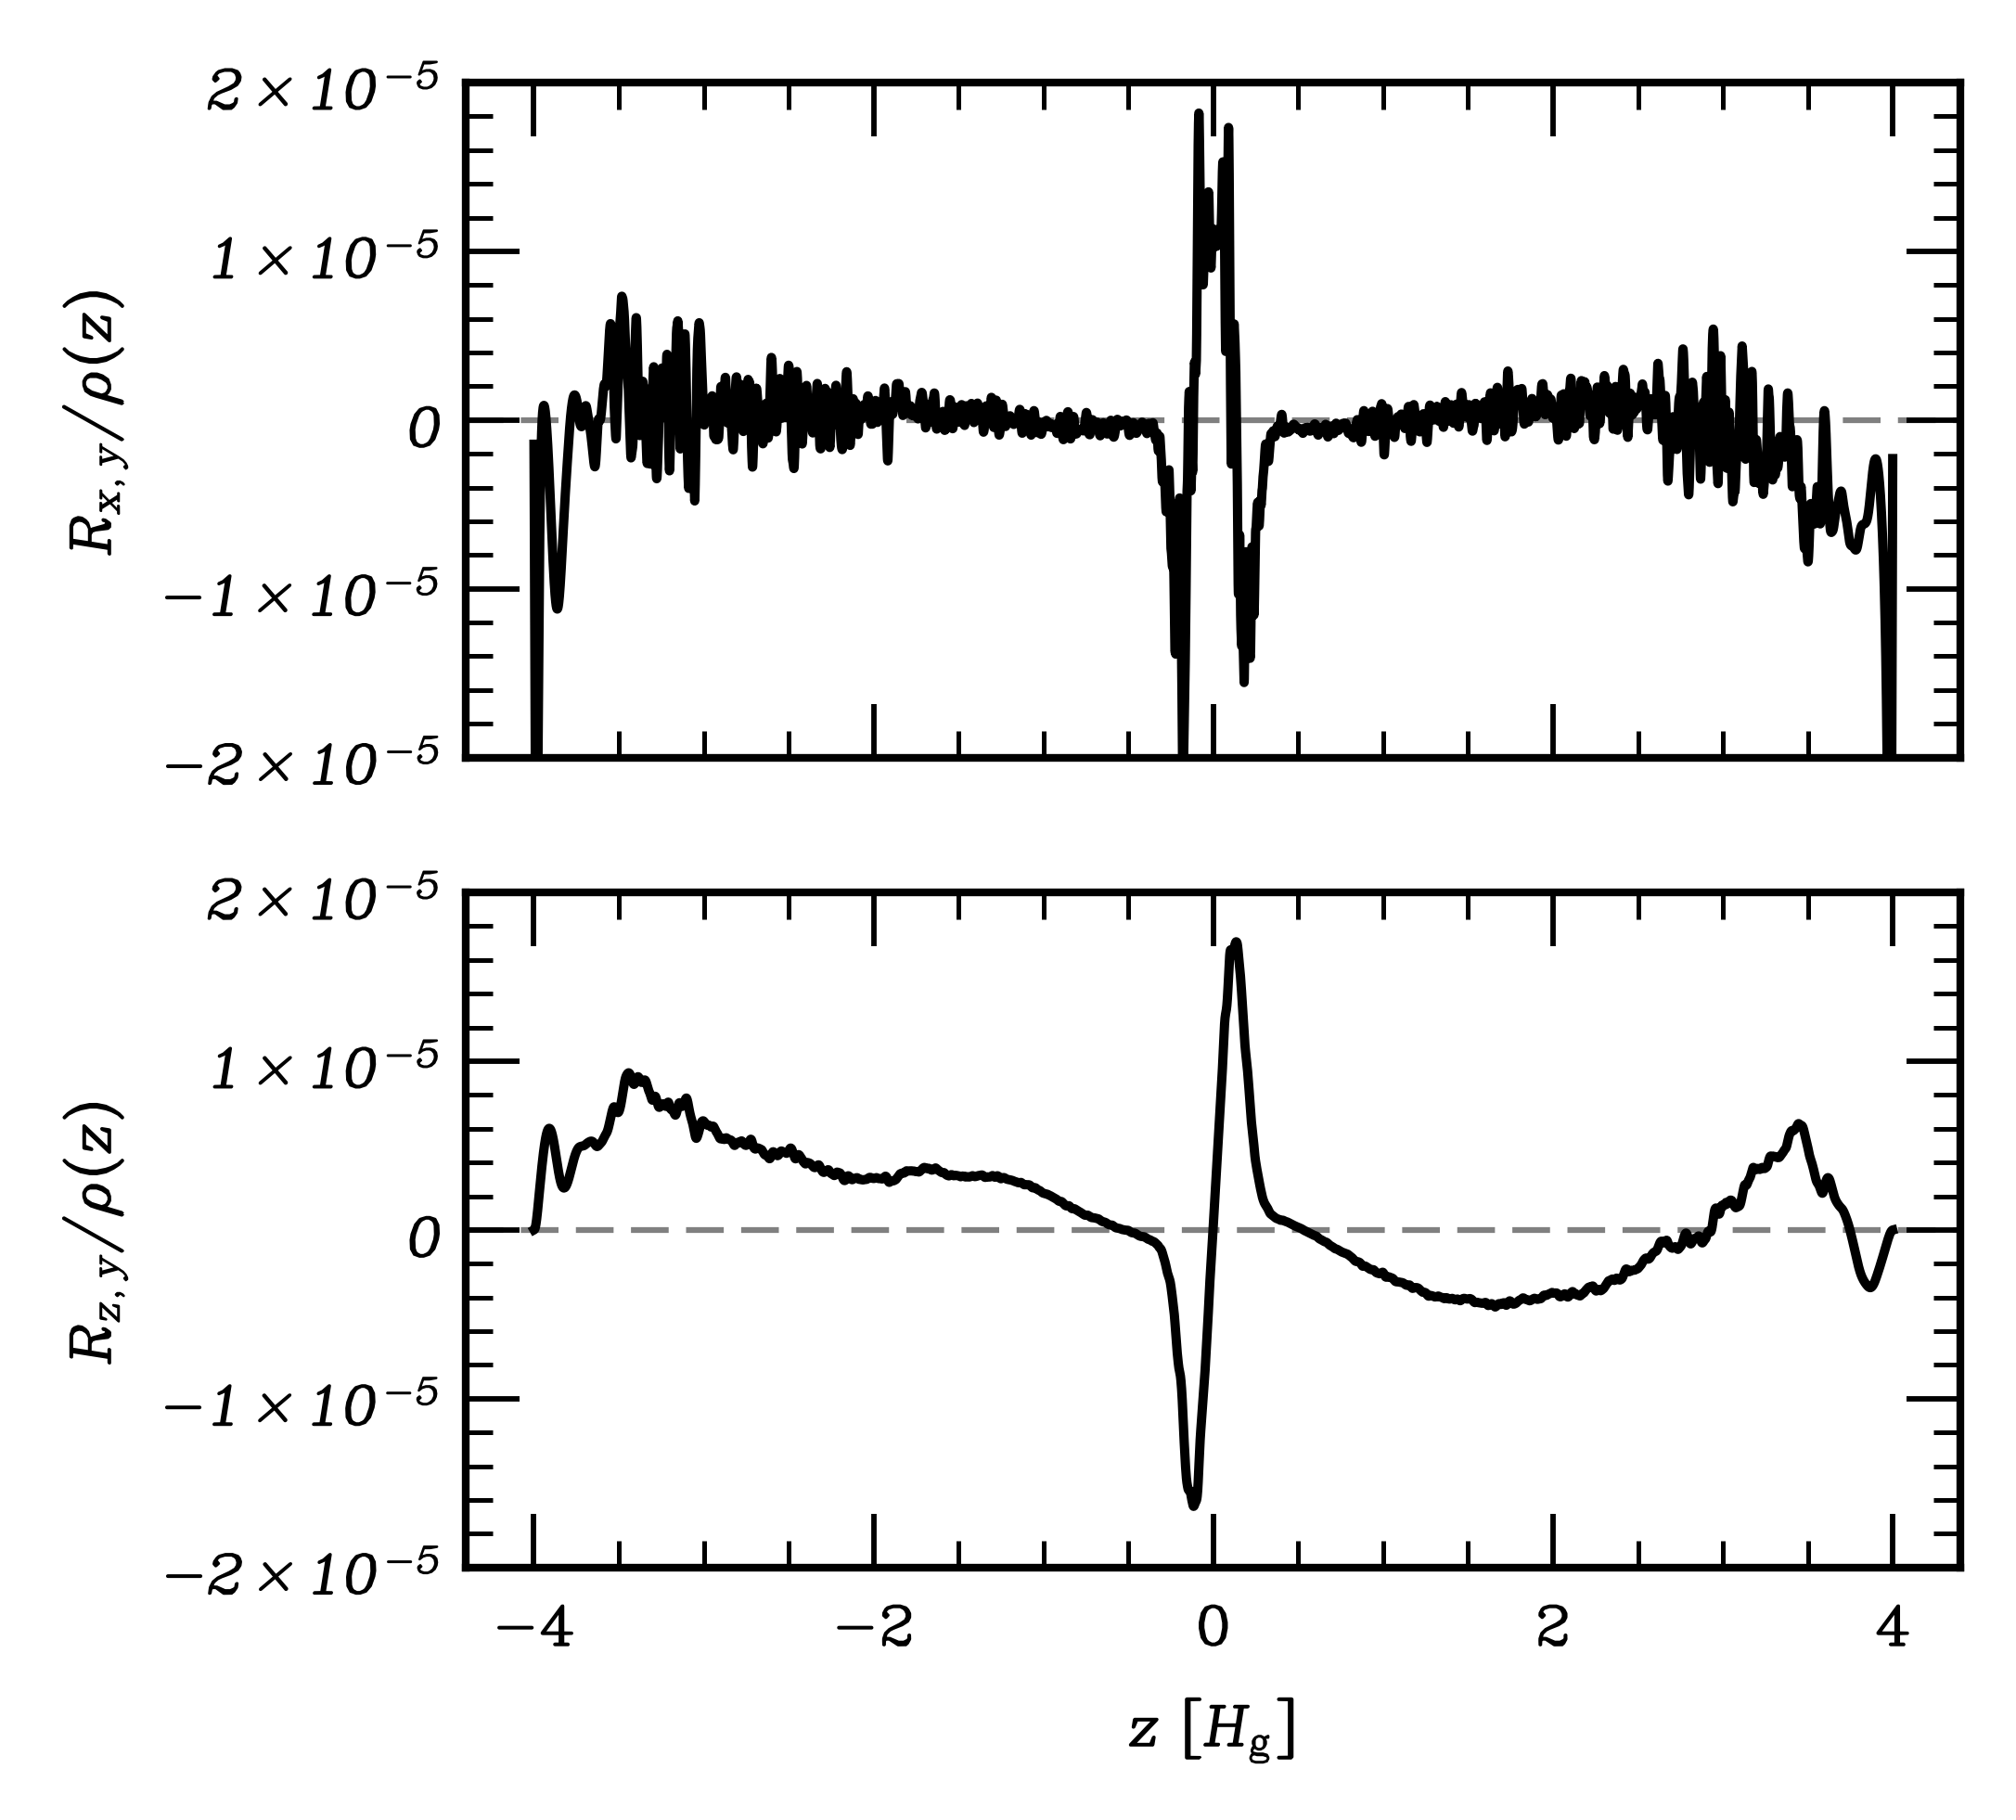

In [39]:
run_name = 'DVSI_gas_2D_Z05_eta05_a5_tse3_hg4x5'
folder = 'DVSI/'
dir = f'/Volumes/datajmatthijsse/phd_project2/raw_data/{folder+run_name}/fargo3d/'
# read in the data from the directories
coord = vt.Coordinates(dir)
pf = vt.PolyFluid(dir)
dt = vt.time_stamps(dir, 2)[1]
frames = vt.time_stamps(dir, vt.max_save(dir))
print(frames[-1]*dt)
print(coord.dz)

n = 250  #assume you have reached 10 outputs. Your mileage may vary.
z = coord.z
nz=int(coord.nz) #Radial resolution. Adapt to your needs if you altered the par file

renyx =(np.fromfile(dir+'monitor/gas/'+"renyx_1d_Z_raw.dat"))[-n*10*nz:].reshape(n*10,nz)
renzx =(np.fromfile(dir+'monitor/gas/'+"renzx_1d_Z_raw.dat"))[-n*10*nz:].reshape(n*10,nz)

tau = [1e-3]
alpha = 1e-5

Z = 0.05
eta = 0.05
z, rhog, gas_vx, gas_vy, gas_vz, ax_gas, ay_gas, az_gas, dust_rho, dust_ux, dust_uy, dust_uz, sigma, rho, stokes, weights = \
    f.anytical(metallicity=Z, hg=4, tau=tau, eta=eta, alpha_viscosity=alpha, z=z)

fig, ax = plt.subplots(2,1, sharex=True)
ax[0].axhline(0.0, color="0.5", linestyle="--", linewidth=0.75, zorder=0)
ax[1].axhline(0.0, color="0.5", linestyle="--", linewidth=0.75, zorder=0)

ax[0].plot(z,np.mean(renyx,axis=0)/coord.dz/rhog)
ax[0].set_ylabel(r'$R_{x,y}/\rho(z)$')
ax[0].set_ylim(-2e-5,2e-5)
ax[0].set_yticklabels([r'$-2 \times 10^{-5}$',r'$-1 \times 10^{-5}$',r'$0$',r'$1 \times 10^{-5}$',r'$2 \times 10^{-5}$'])

ax[1].plot(z,np.mean(renzx,axis=0)/coord.dz/rhog)
ax[1].set_ylabel(r'$R_{z,y}/\rho(z)$')
ax[1].set_ylim(-2e-5,2e-5)
ax[1].set_yticklabels([r'$-2 \times 10^{-5}$',r'$-1 \times 10^{-5}$',r'$0$',r'$1 \times 10^{-5}$',r'$2 \times 10^{-5}$'])

pad = 3
for ax in ax:
    ax.xaxis.set_tick_params(pad=pad)
    ax.yaxis.set_tick_params(pad=pad)

plt.xlabel(r'$z \ [H_\mathrm{g}]$')
fig.savefig("plots/DVSI1_reynolds_500t750.pdf",
            bbox_inches="tight", pad_inches=0.01, dpi=600)
plt.show()


In [ ]:
# run_name = 'DVSI_gas_2D_Z05_eta05_a5_tse3_hg4x5'
# folder = 'DVSI/'
# dir = f'/Volumes/datajmatthijsse/phd_project2/raw_data/{folder+run_name}/fargo3d/'
# # read in the data from the directories
# coord = vt.Coordinates(dir)
# pf = vt.PolyFluid(dir)
# dt = vt.time_stamps(dir, 2)[1]
# frames = vt.time_stamps(dir, vt.max_save(dir))
# print(frames[-1]*dt)

# n = 250  #assume you have reached 10 outputs. Your mileage may vary.
# z = coord.z
# nz=int(coord.nz) #Radial resolution. Adapt to your needs if you altered the par file

# renyx =(np.fromfile(dir+'monitor/gas/'+"ryx_1d_Z_raw.dat"))[-n*10*nz:].reshape(n*10,nz)
# print('loaded one')
# renzx =(np.fromfile(dir+'monitor/gas/'+"rzx_1d_Z_raw.dat"))[-n*10*nz:].reshape(n*10,nz)

# tau = [1e-3]
# alpha = 1e-5
# Z = 0.05
# eta = 0.05
# z, rhog, gas_vx, gas_vy, gas_vz, ax_gas, ay_gas, az_gas, dust_rho, dust_ux, dust_uy, dust_uz, sigma, rho, stokes, weights = \
#     f.anytical(metallicity=Z, hg=4, tau=tau, eta=eta, alpha_viscosity=alpha, z=z)
# print(z)
# plt.imshow(renzx)

# fig, ax = plt.subplots(2,1, sharex=True)
# ax[0].axhline(0.0, color="0.5", linestyle="--", linewidth=0.75, zorder=0)
# ax[1].axhline(0.0, color="0.5", linestyle="--", linewidth=0.75, zorder=0)

# ax[0].plot(z,np.mean(renyx,axis=0)/coord.dz/rhog)
# ax[0].set_ylabel(r'$R_{x,y}/\rho(z)$')
# # ax[0].set_ylim(-2e-5,2e-5)

# ax[1].plot(z,np.mean(renzx,axis=0)/coord.dz/rhog)
# ax[1].set_ylabel(r'$R_{z,y}/\rho(z)$')
# # ax[1].set_ylim(-2e-5,2e-5)



# plt.xlabel(r'$z \ [H_\mathrm{g}]$')



750.0
loaded one


In [ ]:
# # paper
# # Function to adjust color brightness
# def adjust_brightness(color, factor):
#     rgb = mcolors.hex2color(color)
#     hsv = mcolors.rgb_to_hsv(rgb)
#     hsv = (hsv[0],  min(1.0, hsv[1] * 1/factor), min(1.0, hsv[2] * factor))  # Ensure brightness stays within [0, 1]
#     return mcolors.hsv_to_rgb(hsv)


# colorb =sns.color_palette("colorblind")
# colorb[5] = sns.color_palette("colorblind")[7]

# light = [mcolors.to_hex(adjust_brightness(color, 1.33)) for color in colorb]
# dark = [mcolors.to_hex(adjust_brightness(color, 1/1.33)) for color in colorb]
# # colorb[5] = sns.color_palette("colorblind")[7]
# light[5] = sns.color_palette("pastel")[7]
# # dark[5] = sns.color_palette("dark")[7]

# lwidth=.75
# cmap = sns.color_palette("flare", as_cmap=True)

# width_plot_s = 3.46457 #inches
# width_plot_l = 7.08661 #inches
# figsize_s = (width_plot_s, width_plot_s*3/4)
# figsize_l= (width_plot_l, width_plot_l*2/3)
# figsize_tall = ((width_plot_s, width_plot_s*5/4))
# colorback = 'white'#(32.2/100, 2/100, 48.2/100)
# colortxt = 'black'#(88.2/100, 91/100, 92.2/100)
# plt.rc('figure', figsize=(3.54331, 3.54331/(16/9)), dpi=600, facecolor=colorback, edgecolor=colorback)
# plt.rc('savefig', bbox='tight', dpi=600)
# plt.rc('lines', linewidth=lwidth)
# plt.rc('xtick', labelsize=6, color=colortxt, top=True) 
# plt.rc('xtick.major', size=3.5*lwidth, width=0.8*lwidth)
# plt.rc('ytick.major', size=3.5*lwidth, width=0.8*lwidth)
# plt.rc('xtick.minor', size=2*lwidth, width=0.6*lwidth)
# plt.rc('ytick.minor', size=2*lwidth, width=0.6*lwidth)
# plt.rc('ytick', labelsize=6, color=colortxt, right=True)
# plt.rc('font', size=7, family='serif', serif='Helvetica') # use a serif font
# plt.rcParams['pdf.fonttype']=42
# plt.rc('mathtext', fontset= 'dejavusans')
# plt.rc('axes', facecolor=colorback, edgecolor=colortxt, titlesize=7, titlecolor=colortxt,  labelsize=7, labelcolor=colortxt, linewidth=.8*lwidth) #fontsize of the title #fontsize of the x and y labels
# plt.rc('legend', labelcolor=colortxt, fontsize=7, title_fontsize=7, framealpha=0.6, markerscale = .6) #fontsize of the legend

In [ ]:
#powerpoint
#  colorb =sns.color_palette("colorblind") 
# colorb[5] = sns.color_palette("colorblind")[7] lwidth=2. 
# cmap = sns.color_palette("flare", as_cmap=True) 
# width_plot_s = 6.5 #inches width_plot_l = 13 
# #inches figsize_s = (width_plot_s, width_plot_s*3/4) 
# figsize_l= (width_plot_l, width_plot_l*2/3) 
# figsize_tall = ((width_plot_s, width_plot_s*5/4)) 
# colorback = 'white'#(32.2/100, 2/100, 48.2/100) 
# colortxt = 'black'#(88.2/100, 91/100, 92.2/100) 
# plt.rc('figure', figsize=(width_plot_s, width_plot_s*(9/16)), dpi=600, facecolor=colorback, edgecolor=colorback) 
# plt.rc('savefig', bbox='tight', dpi=600) plt.rc('lines', linewidth=lwidth) 
# plt.rc('xtick', labelsize=18, color=colortxt, top=True) 
# plt.rc('ytick', labelsize=18, color=colortxt, right=True) 
# plt.rc('font', size=24, family='sans-serif', serif='Ariel') # use a serif font plt.rc('mathtext', fontset= 'dejavusans') 
# plt.rc('axes', facecolor=colorback, edgecolor=colortxt, titlesize=24, titlecolor=colortxt, labelsize=24, labelcolor=colortxt, linewidth=.8*lwidth) #fontsize of the title #fontsize of the x and y labels 
# plt.rc('legend', labelcolor=colortxt, fontsize=18, title_fontsize=18, framealpha=0.5, markerscale = .6*lwidth) #fontsize of the legend

In [ ]:
def multi_heatmaps(
    dens, coordx, coordz,
    *,
    width_plot=7.08661,
    max_panels=6,

    # layout / margins (inches)
    gap_x=0.08,
    gap_y=0.10,
    left=0.33, right=0.06,
    bottom=0.32, top=0.06,

    # colorbar geometry (inches)
    cbar_h=0.09,
    cbar_pad_top=0.025,
    cbar_pad_bottom=0.12,

    # reserve extra clearance specifically for the shared xlabel in 2-row layout
    xlabel_clearance=0.10,

    # appearance
    cmap="viridis",
    rasterized=True,

    # color scaling
    cbar_mode="per_panel",
    vmin_floor=1e-4,
    vmax_floor=1e-2,
    symmetric=False,
    use_lognorm=True,
    vmin=None,
    vmax=None,

    # labels
    xlabel=r"$x$",
    ylabel=r"$z$",
    omegat=None,
    loc_omegat=[0.45, 1],
    cbar_labels=None,


    # per-panel corner text
    panel_text=None,
    panel_text_kwargs=None,

    # ticks
    x_tick_step=0.5,
    y_tick_step=0.5,
    x_tick_fmt="%.1f",
    y_tick_fmt="%.1f",
    show_inner_yticks=False,
    show_inner_xticks=False,

    # layout rule
    two_row_aspect_threshold=2.0
):
    """
    N=1..6 heatmaps with fixed figure width and minimal whitespace.

    coordx/coordz may be:
      - a single 1D array (shared across all panels), OR
      - a list/tuple of length N with per-panel 1D arrays.

    vmin, vmax, vmin_floor, vmax_floor may each be:
      - None
      - a scalar number
      - a string keyword
      - a list/tuple of length N containing any mix of the above

    Supported string keywords:
      - "auto"   : let the function determine it from the panel/group data
      - "min"    : use data minimum
      - "max"    : use data maximum
      - "floor"  : only meaningful for vmin_floor / vmax_floor -> same as auto floor logic
    """

    dens = list(dens)
    N = len(dens)
    if not (1 <= N <= max_panels):
        raise ValueError(f"Expected 1..{max_panels} heatmaps; got {N}.")

    # mpl.rcParams.update({
    #     "font.size": fontlabels,
    #     "axes.labelsize": fontlabels,
    #     "axes.titlesize": fontlabels,
    #     "xtick.labelsize": fontticks,
    #     "ytick.labelsize": fontticks,
    #     "axes.linewidth": .6*lwidth,
    #     "xtick.major.size": 3.5*lwidth,
    #     "xtick.major.width": 0.8*lwidth,
    #     "ytick.major.size": 3.5*lwidth,
    #     "ytick.major.width": 0.8*lwidth,
    #     "xtick.minor.size": 2*lwidth,
    #     "xtick.minor.width": 0.6*lwidth,
    #     "ytick.minor.size": 2*lwidth,
    #     "ytick.minor.width": 0.6*lwidth,
    # })

    # ------------------------------------------------------------------
    # helpers
    # ------------------------------------------------------------------
    def _as_per_panel_coords(c, name):
        if isinstance(c, (list, tuple)) and len(c) == N:
            return list(c)
        if isinstance(c, np.ndarray) and c.dtype == object and c.ndim == 1 and len(c) == N:
            return list(c)
        return [c] * N

    def _coords_equal(a, b):
        a = np.asarray(a)
        b = np.asarray(b)
        return a.shape == b.shape and np.array_equal(a, b)

    def _broadcast_norm_param(x, name, cbar_mode, N):
        """
        Broadcast norm-related parameters depending on cbar_mode.

        Accepts:
        - None / scalar / str
        - list/tuple
        - 1D object ndarray

        Returns a list of length N for downstream per-panel logic.
        """

        # scalar / single string / None -> broadcast to all panels
        if not isinstance(x, (list, tuple, np.ndarray)) or isinstance(x, str):
            return [x] * N

        # ndarray -> convert
        if isinstance(x, np.ndarray):
            if x.ndim != 1:
                raise ValueError(f"`{name}` array must be 1D.")
            vals = list(x)
        else:
            vals = list(x)

        L = len(vals)

        if cbar_mode == "per_panel":
            if L != N:
                raise ValueError(
                    f"With cbar_mode='per_panel', `{name}` must have length N={N}; got {L}."
                )
            return vals

        elif cbar_mode == "shared":
            if L == 0:
                raise ValueError(f"`{name}` list cannot be empty.")
            if L == 1:
                return vals * N
            if L == N:
                # allow, but effectively shared mode only uses first item later
                return vals
            raise ValueError(
                f"With cbar_mode='shared', `{name}` must be a scalar/str/None, "
                f"or a list of length 1"
                f"{' or N' if N > 1 else ''}; got {L}."
            )

        elif cbar_mode == "first_individual_rest_shared":
            if L == 0:
                raise ValueError(f"`{name}` list cannot be empty.")
            if L == 1:
                # same for first and rest
                return vals * N
            if L == 2:
                # [first, rest]
                return [vals[0]] + [vals[1]] * (N - 1)
            if L == N:
                # accept full per-panel specification too
                return vals
            raise ValueError(
                f"With cbar_mode='first_individual_rest_shared', `{name}` must be a scalar/str/None, "
                f"or a list of length 1, 2, or N={N}; got {L}."
            )

        else:
            raise ValueError(f"Unknown cbar_mode={cbar_mode!r}")
        
    def _broadcast_bool_param(x, name, cbar_mode, N):
        """
        Broadcast boolean norm flags depending on cbar_mode.

        Accepts:
        - bool
        - list/tuple of bools
        - 1D ndarray of bools

        Returns a list of length N.
        """

        if isinstance(x, (bool, np.bool_)):
            return [bool(x)] * N

        if isinstance(x, np.ndarray):
            if x.ndim != 1:
                raise ValueError(f"`{name}` array must be 1D.")
            vals = list(x)
        elif isinstance(x, (list, tuple)):
            vals = list(x)
        else:
            raise TypeError(f"`{name}` must be a bool or a list/tuple/1D ndarray of bools.")

        if not all(isinstance(v, (bool, np.bool_)) for v in vals):
            raise TypeError(f"All entries of `{name}` must be booleans.")

        vals = [bool(v) for v in vals]
        L = len(vals)

        if cbar_mode == "per_panel":
            if L != N:
                raise ValueError(
                    f"With cbar_mode='per_panel', `{name}` must have length N={N}; got {L}."
                )
            return vals

        elif cbar_mode == "shared":
            if L == 0:
                raise ValueError(f"`{name}` list cannot be empty.")
            if L == 1:
                return vals * N
            if L == N:
                # Allowed, but shared mode uses only item 0 for the shared norm.
                return vals
            raise ValueError(
                f"With cbar_mode='shared', `{name}` must be a bool, "
                f"or a list of length 1"
                f"{' or N' if N > 1 else ''}; got {L}."
            )

        elif cbar_mode == "first_individual_rest_shared":
            if L == 0:
                raise ValueError(f"`{name}` list cannot be empty.")
            if L == 1:
                return vals * N
            if L == 2:
                # [first, rest]
                return [vals[0]] + [vals[1]] * (N - 1)
            if L == N:
                return vals
            raise ValueError(
                f"With cbar_mode='first_individual_rest_shared', `{name}` must be a bool, "
                f"or a list of length 1, 2, or N={N}; got {L}."
            )

        else:
            raise ValueError(f"Unknown cbar_mode={cbar_mode!r}")

    def _finite_stats(d):
        d = np.asarray(d, dtype=float)
        finite = d[np.isfinite(d)]
        if finite.size == 0:
            return {
                "finite": finite,
                "finite_pos": finite,
                "has_finite": False,
                "has_pos": False,
                "min": None,
                "max": None,
                "pos_min": None,
                "pos_max": None,
            }

        finite_pos = finite[finite > 0]
        return {
            "finite": finite,
            "finite_pos": finite_pos,
            "has_finite": True,
            "has_pos": finite_pos.size > 0,
            "min": float(np.nanmin(finite)),
            "max": float(np.nanmax(finite)),
            "pos_min": float(np.nanmin(finite_pos)) if finite_pos.size else None,
            "pos_max": float(np.nanmax(finite_pos)) if finite_pos.size else None,
        }

    def _resolve_bound(value, *, stats, which, use_lognorm_i, default=None):
        """
        Resolve panel/group bound for vmin/vmax.
        which in {"vmin", "vmax"}.
        """
        if value is None:
            return default

        if isinstance(value, str):
            key = value.lower().strip()
            if key == "auto":
                return default
            if key == "min":
                if use_lognorm_i:
                    return stats["pos_min"] if stats["has_pos"] else default
                return stats["min"] if stats["has_finite"] else default
            if key == "max":
                if use_lognorm_i:
                    return stats["pos_max"] if stats["has_pos"] else default
                return stats["max"] if stats["has_finite"] else default
            raise ValueError(
                f"Unsupported string for `{which}`: {value!r}. "
                f"Use None, number, 'auto', 'min', or 'max'."
            )

        return float(value)

    def _resolve_floor(value, *, stats, which, use_lognorm_i, default=None):
        """
        Resolve panel/group floor for vmin_floor/vmax_floor.
        which in {"vmin_floor", "vmax_floor"}.
        """
        if value is None:
            return None

        if isinstance(value, str):
            key = value.lower().strip()
            if key in {"auto", "floor"}:
                return default
            if key == "min":
                if use_lognorm_i:
                    return stats["pos_min"] if stats["has_pos"] else default
                return stats["min"] if stats["has_finite"] else default
            if key == "max":
                if use_lognorm_i:
                    return stats["pos_max"] if stats["has_pos"] else default
                return stats["max"] if stats["has_finite"] else default
            raise ValueError(
                f"Unsupported string for `{which}`: {value!r}. "
                f"Use None, number, 'auto', 'floor', 'min', or 'max'."
            )

        return float(value)

    def make_norm_for_data(
        d,
        *,
        vmin_i,
        vmax_i,
        vmin_floor_i,
        vmax_floor_i,
        symmetric_i,
        use_lognorm_i,
    ):
        d = np.asarray(d, dtype=float)
        stats = _finite_stats(d)

        if symmetric_i and use_lognorm_i:
            raise ValueError(
                "`symmetric=True` and `use_lognorm=True` are incompatible for the same panel."
            )

        if symmetric_i:
            if not stats["has_finite"]:
                vv_auto = 1.0
            else:
                vv_auto = float(np.nanmax(np.abs(stats["finite"])))

            vv = _resolve_bound(
                vmax_i,
                stats=stats,
                which="vmax",
                use_lognorm_i=False,
                default=vv_auto,
            )
            v0 = _resolve_bound(
                vmin_i,
                stats=stats,
                which="vmin",
                use_lognorm_i=False,
                default=-vv,
            )

            if v0 is None:
                v0 = -vv
            if vv is None:
                vv = abs(v0)

            return mpl.colors.Normalize(vmin=float(v0), vmax=float(vv)), "neither"

        if use_lognorm_i:
            if not stats["has_pos"]:
                raise ValueError("LogNorm requested but data has no positive finite values.")

            dmin = stats["pos_min"]
            dmax = stats["pos_max"]

            vmax_floor_res = _resolve_floor(
                vmax_floor_i,
                stats=stats,
                which="vmax_floor",
                use_lognorm_i=True,
                default=vmax_floor_i,
            )
            vmin_floor_res = _resolve_floor(
                vmin_floor_i,
                stats=stats,
                which="vmin_floor",
                use_lognorm_i=True,
                default=vmin_floor_i,
            )

            vv = _resolve_bound(
                vmax_i,
                stats=stats,
                which="vmax",
                use_lognorm_i=True,
                default=dmax,
            )
            if vmax_floor_res is not None:
                vv = max(vv, float(vmax_floor_res))

            if vmin_i is None or (
                isinstance(vmin_i, str) and vmin_i.lower().strip() == "auto"
            ):
                if vmin_floor_res is None:
                    v0 = dmin
                else:
                    v0 = max(float(vmin_floor_res), dmin)
            else:
                v0 = _resolve_bound(
                    vmin_i,
                    stats=stats,
                    which="vmin",
                    use_lognorm_i=True,
                    default=dmin,
                )

            below = dmin < v0
            above = dmax > vv
            if below and above:
                ext = "both"
            elif below:
                ext = "min"
            elif above:
                ext = "max"
            else:
                ext = "neither"

            v0 = max(float(v0), np.finfo(float).tiny)
            vv = max(float(vv), v0 * (1 + 1e-12))

            return mpl.colors.LogNorm(vmin=v0, vmax=vv), ext

        if not stats["has_finite"]:
            v0 = _resolve_bound(
                vmin_i,
                stats=stats,
                which="vmin",
                use_lognorm_i=False,
                default=0.0,
            )
            vv = _resolve_bound(
                vmax_i,
                stats=stats,
                which="vmax",
                use_lognorm_i=False,
                default=1.0,
            )
            return mpl.colors.Normalize(vmin=float(v0), vmax=float(vv)), "neither"

        v0 = _resolve_bound(
            vmin_i,
            stats=stats,
            which="vmin",
            use_lognorm_i=False,
            default=stats["min"],
        )
        vv = _resolve_bound(
            vmax_i,
            stats=stats,
            which="vmax",
            use_lognorm_i=False,
            default=stats["max"],
        )

        if v0 == vv:
            vv = v0 + 1e-12

        return mpl.colors.Normalize(vmin=float(v0), vmax=float(vv)), "neither"

        if use_lognorm:
            if not stats["has_pos"]:
                raise ValueError("LogNorm requested but data has no positive finite values.")

            dmin = stats["pos_min"]
            dmax = stats["pos_max"]

            vmax_floor_res = _resolve_floor(
                vmax_floor_i, stats=stats, which="vmax_floor", default=vmax_floor_i
            )
            vmin_floor_res = _resolve_floor(
                vmin_floor_i, stats=stats, which="vmin_floor", default=vmin_floor_i
            )

            vv = _resolve_bound(vmax_i, stats=stats, which="vmax", default=dmax)
            if vmax_floor_res is not None:
                vv = max(vv, float(vmax_floor_res))

            if vmin_i is None or (isinstance(vmin_i, str) and vmin_i.lower().strip() == "auto"):
                if vmin_floor_res is None:
                    v0 = dmin
                else:
                    v0 = max(float(vmin_floor_res), dmin)
            else:
                v0 = _resolve_bound(vmin_i, stats=stats, which="vmin", default=dmin)

            below = dmin < v0
            above = dmax > vv
            if below and above:
                ext = "both"
            elif below:
                ext = "min"
            elif above:
                ext = "max"
            else:
                ext = "neither"

            v0 = max(float(v0), np.finfo(float).tiny)
            vv = max(float(vv), v0 * (1 + 1e-12))
            return mpl.colors.LogNorm(vmin=v0, vmax=vv), ext

        if not stats["has_finite"]:
            v0 = _resolve_bound(vmin_i, stats=stats, which="vmin", default=0.0)
            vv = _resolve_bound(vmax_i, stats=stats, which="vmax", default=1.0)
            return mpl.colors.Normalize(vmin=float(v0), vmax=float(vv)), "neither"

        v0 = _resolve_bound(vmin_i, stats=stats, which="vmin", default=stats["min"])
        vv = _resolve_bound(vmax_i, stats=stats, which="vmax", default=stats["max"])

        if v0 == vv:
            vv = v0 + 1e-12

        return mpl.colors.Normalize(vmin=float(v0), vmax=float(vv)), "neither"

    # ------------------------------------------------------------------
    # coords
    # ------------------------------------------------------------------
    coordx_list = _as_per_panel_coords(coordx, "coordx")
    coordz_list = _as_per_panel_coords(coordz, "coordz")

    can_share = True
    for i in range(1, N):
        if not _coords_equal(coordx_list[0], coordx_list[i]) or not _coords_equal(coordz_list[0], coordz_list[i]):
            can_share = False
            break

    # ------------------------------------------------------------------
    # colormaps
    # ------------------------------------------------------------------
    if isinstance(cmap, (list, tuple)):
        cmaps = list(cmap)

        if len(cmaps) == N:
            pass
        elif cbar_mode == "first_individual_rest_shared" and len(cmaps) == 2:
            cmaps = [cmaps[0]] + [cmaps[1]] * (N - 1)
        elif cbar_mode == "shared" and len(cmaps) == 1:
            cmaps = cmaps * N
        else:
            raise ValueError(
                f"If `cmap` is a list/tuple, it must have length N={N}"
                f"{' or length 2 when cbar_mode=first_individual_rest_shared' if cbar_mode == 'first_individual_rest_shared' else ''}; "
                f"got {len(cmaps)}."
            )
    else:
        cmaps = [cmap] * N

    # ------------------------------------------------------------------
    # panel text
    # ------------------------------------------------------------------
    if panel_text is None:
        panel_texts = [None] * N
    elif isinstance(panel_text, str):
        panel_texts = [panel_text] * N
    else:
        panel_texts = list(panel_text)
        if len(panel_texts) != N:
            raise ValueError(f"If `panel_text` is a list/tuple, it must have length N={N}; got {len(panel_texts)}.")

    if panel_text_kwargs is None:
        panel_text_kwargs = dict(
            color="white",
            ha="left",
            va="top",
            transform=None,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="black", alpha=0.35, linewidth=0.0),
        )

    # ------------------------------------------------------------------
    # panel sizing
    # ------------------------------------------------------------------
    aspects = []
    for i in range(N):
        cx = np.asarray(coordx_list[i])
        cz = np.asarray(coordz_list[i])
        if cx.ndim != 1 or cz.ndim != 1:
            raise ValueError("coordx/coordz must be 1D arrays (or lists of 1D arrays).")
        aspects.append(len(cz) / max(1, len(cx)))
    data_aspect = float(max(aspects))

    use_two_rows = (N % 2 == 0) and (N > 1) and (data_aspect < two_row_aspect_threshold)
    ncols_panels = (N // 2) if use_two_rows else N

    valid_cbar_modes = {"per_panel", "shared", "first_individual_rest_shared"}
    if cbar_mode not in valid_cbar_modes:
        raise ValueError(f"`cbar_mode` must be one of {valid_cbar_modes}; got {cbar_mode!r}")

    # ------------------------------------------------------------------
    # cbar labels
    # ------------------------------------------------------------------
    if cbar_mode == "per_panel":
        if cbar_labels is None:
            cbar_labels = [""] * N
        elif isinstance(cbar_labels, str):
            cbar_labels = [cbar_labels] * N
        else:
            cbar_labels = list(cbar_labels)
        if len(cbar_labels) != N:
            raise ValueError("With cbar_mode='per_panel', cbar_labels must be None, a str, or a list of N strings.")

    elif cbar_mode == "shared":
        if isinstance(cbar_labels, (list, tuple)):
            cbar_labels = cbar_labels[0] if len(cbar_labels) else ""
        elif cbar_labels is None:
            cbar_labels = ""

    elif cbar_mode == "first_individual_rest_shared":
        if cbar_labels is None:
            cbar_labels = ["", ""]
        elif isinstance(cbar_labels, str):
            cbar_labels = [cbar_labels, cbar_labels]
        else:
            cbar_labels = list(cbar_labels)
            if len(cbar_labels) != 2:
                raise ValueError(
                    "With cbar_mode='first_individual_rest_shared', "
                    "cbar_labels must be None, a str, or a 2-item list: "
                    "[first_panel_label, shared_rest_label]."
                )

    # ------------------------------------------------------------------
    # NEW: broadcast norm parameters per panel
    # ------------------------------------------------------------------
    vmin_list = _broadcast_norm_param(vmin, "vmin", cbar_mode, N)
    vmax_list = _broadcast_norm_param(vmax, "vmax", cbar_mode, N)
    vmin_floor_list = _broadcast_norm_param(vmin_floor, "vmin_floor", cbar_mode, N)
    vmax_floor_list = _broadcast_norm_param(vmax_floor, "vmax_floor", cbar_mode, N)
    symmetric_list = _broadcast_bool_param(symmetric, "symmetric", cbar_mode, N)
    use_lognorm_list = _broadcast_bool_param(use_lognorm, "use_lognorm", cbar_mode, N)

    # ------------------------------------------------------------------
    # norms
    # ------------------------------------------------------------------
    if cbar_mode == "per_panel":
        norms_ext = [
            make_norm_for_data(
                dens[i],
                vmin_i=vmin_list[i],
                vmax_i=vmax_list[i],
                vmin_floor_i=vmin_floor_list[i],
                vmax_floor_i=vmax_floor_list[i],
                symmetric_i=symmetric_list[i],
                use_lognorm_i=use_lognorm_list[i],
            )
            for i in range(N)
        ]

    elif cbar_mode == "shared":
        all_data = np.concatenate([np.ravel(np.asarray(d)) for d in dens])
        all_data = all_data[np.isfinite(all_data)]
        if all_data.size == 0:
            raise ValueError("All dens arrays are empty/non-finite.")

        # shared mode: use first entry if list-like, otherwise all were already broadcast
        global_norm, global_ext = make_norm_for_data(
            all_data,
            vmin_i=vmin_list[0],
            vmax_i=vmax_list[0],
            vmin_floor_i=vmin_floor_list[0],
            vmax_floor_i=vmax_floor_list[0],
            symmetric_i=symmetric_list[0],
            use_lognorm_i=use_lognorm_list[0],
        )
        norms_ext = [(global_norm, global_ext)] * N

    elif cbar_mode == "first_individual_rest_shared":
        if N == 1:
            norms_ext = [
                make_norm_for_data(
                    dens[0],
                    vmin_i=vmin_list[0],
                    vmax_i=vmax_list[0],
                    vmin_floor_i=vmin_floor_list[0],
                    vmax_floor_i=vmax_floor_list[0],
                    symmetric_i=symmetric_list[0],
                    use_lognorm_i=use_lognorm_list[0],
                )
            ]
        else:
            first_norm_ext = make_norm_for_data(
                dens[0],
                vmin_i=vmin_list[0],
                vmax_i=vmax_list[0],
                vmin_floor_i=vmin_floor_list[0],
                vmax_floor_i=vmax_floor_list[0],
                symmetric_i=symmetric_list[0],
                use_lognorm_i=use_lognorm_list[0],
            )

            rest_data = np.concatenate([np.ravel(np.asarray(d)) for d in dens[1:]])
            rest_data = rest_data[np.isfinite(rest_data)]
            if rest_data.size == 0:
                raise ValueError("Heatmaps 1..N-1 are empty/non-finite.")

            # for the shared-rest group, use item 1 if a list was supplied
            rest_idx = 1
            rest_norm_ext = make_norm_for_data(
                rest_data,
                vmin_i=vmin_list[rest_idx],
                vmax_i=vmax_list[rest_idx],
                vmin_floor_i=vmin_floor_list[rest_idx],
                vmax_floor_i=vmax_floor_list[rest_idx],
                symmetric_i=symmetric_list[rest_idx],
                use_lognorm_i=use_lognorm_list[rest_idx],
            )
            norms_ext = [first_norm_ext] + [rest_norm_ext] * (N - 1)

    # ------------------------------------------------------------------
    # geometry
    # ------------------------------------------------------------------
    W_axes_total = width_plot - left - right - (ncols_panels - 1) * gap_x
    if W_axes_total <= 0:
        raise ValueError("width_plot too small for requested margins/gaps.")

    w_ax = W_axes_total / ncols_panels
    h_ax = w_ax * data_aspect

    if not use_two_rows:
        vbands = [bottom, h_ax, cbar_pad_top, cbar_h, top]
        vnames = ["bottom", "heat_top", "pad_top", "cbar_top", "top"]
    else:
        if cbar_mode == "per_panel":
            vbands = [bottom, xlabel_clearance, cbar_h, cbar_pad_bottom, h_ax, gap_y, h_ax, cbar_pad_top, cbar_h, top]
            vnames = ["bottom", "xlabel_clear", "cbar_bot", "pad_bot", "heat_bot", "gap_y",
                      "heat_top", "pad_top", "cbar_top", "top"]
        else:
            vbands = [bottom, xlabel_clearance, h_ax, gap_y, h_ax, cbar_pad_top, cbar_h, top]
            vnames = ["bottom", "xlabel_clear", "heat_bot", "gap_y", "heat_top", "pad_top", "cbar_top", "top"]

    height_fig = float(sum(vbands))
    fig = plt.figure(figsize=(width_plot, height_fig))

    horiz = [Size.Fixed(left)]
    for j in range(ncols_panels):
        horiz.append(Size.Fixed(w_ax))
        if j < ncols_panels - 1:
            horiz.append(Size.Fixed(gap_x))
    horiz.append(Size.Fixed(right))

    divider = Divider(fig, (0, 0, 1, 1), horiz, [Size.Fixed(v) for v in vbands], aspect=False)
    name_to_ny = {name: i for i, name in enumerate(vnames)}

    def nx_for_col(j):
        return 1 + 2 * j

    # ------------------------------------------------------------------
    # axes + heatmaps
    # ------------------------------------------------------------------
    axes, ims = [], []
    ax_ref = None

    if not use_two_rows:
        top_row_indices = list(range(N))
        bot_row_indices = []
    else:
        top_row_indices = list(range(ncols_panels))
        bot_row_indices = list(range(ncols_panels, N))

    ny_top_heat = name_to_ny["heat_top"]
    ny_bot_heat = name_to_ny.get("heat_bot", None)

    def add_panel_text(ax, text):
        if text is None or text == "":
            return
        kw = dict(panel_text_kwargs)
        kw["transform"] = ax.transAxes
        ax.text(0.02, 0.98, text, **kw)

    def _setup_ticks(ax):
        ax.xaxis.set_major_locator(MultipleLocator(x_tick_step))
        ax.yaxis.set_major_locator(MultipleLocator(y_tick_step))
        ax.xaxis.set_major_formatter(FormatStrFormatter(x_tick_fmt))
        ax.yaxis.set_major_formatter(FormatStrFormatter(y_tick_fmt))

    # Top row
    for j, idx in enumerate(top_row_indices):
        nx = nx_for_col(j)

        if (ax_ref is None) or (not can_share):
            ax = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=nx, ny=ny_top_heat))
            _setup_ticks(ax)
            if ax_ref is None and can_share:
                ax_ref = ax
        else:
            ax = fig.add_axes(
                divider.get_position(),
                axes_locator=divider.new_locator(nx=nx, ny=ny_top_heat),
                sharex=ax_ref, sharey=ax_ref
            )

        norm, _ = norms_ext[idx]
        cx = coordx_list[idx]
        cz = coordz_list[idx]
        im = ax.pcolormesh(cx, cz, dens[idx], cmap=cmaps[idx], norm=norm,
                           rasterized=rasterized, shading="auto")
        ax.set_aspect("equal")
        # ax.tick_params(length=2.0*lwidth, width=0.8*lwidth, pad=1.5, top=True, right=True)

        add_panel_text(ax, panel_texts[idx])

        axes.append(ax)
        ims.append(im)

    # Bottom row
    for j, idx in enumerate(bot_row_indices):
        nx = nx_for_col(j)

        if can_share:
            ax = fig.add_axes(
                divider.get_position(),
                axes_locator=divider.new_locator(nx=nx, ny=ny_bot_heat),
                sharex=ax_ref, sharey=ax_ref
            )
        else:
            ax = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=nx, ny=ny_bot_heat))
            _setup_ticks(ax)

        norm, _ = norms_ext[idx]
        cx = coordx_list[idx]
        cz = coordz_list[idx]
        im = ax.pcolormesh(cx, cz, dens[idx], cmap=cmaps[idx], norm=norm,
                           rasterized=rasterized, shading="auto")
        ax.set_aspect("equal")
        # ax.tick_params(length=2.0*lwidth, width=0.8*lwidth, pad=1.5, top=True, right=True)

        add_panel_text(ax, panel_texts[idx])

        axes.append(ax)
        ims.append(im)

    # ------------------------------------------------------------------
    # tick label hiding
    # ------------------------------------------------------------------
    if not show_inner_yticks:
        for i_ax, ax in enumerate(axes):
            col = i_ax if not use_two_rows else (i_ax % ncols_panels)
            if col != 0:
                ax.tick_params(labelleft=False)

    if use_two_rows and (not show_inner_xticks):
        for ax in axes[:ncols_panels]:
            ax.tick_params(labelbottom=False)

    # ------------------------------------------------------------------
    # colorbars
    # ------------------------------------------------------------------
    cbs = []

    if cbar_mode == "shared":
        ny_cbar = name_to_ny["cbar_top"]
        nx0 = nx_for_col(0)
        nx1 = nx_for_col(ncols_panels - 1) + 1
        cax = fig.add_axes(
            divider.get_position(),
            axes_locator=divider.new_locator(nx=nx0, nx1=nx1, ny=ny_cbar)
        )
        _, extend = norms_ext[0]
        cb = fig.colorbar(ims[-1], cax=cax, orientation="horizontal", extend=extend)
        cax.xaxis.set_ticks_position("top")
        cax.xaxis.set_label_position("top")
        cb.set_label(cbar_labels)
        # cax.tick_params(length=2.0*lwidth, width=.8*lwidth, pad=1.)
        cbs = [cb]

    elif cbar_mode == "per_panel":
        ny_cbar_top = name_to_ny["cbar_top"]
        for j, idx in enumerate(top_row_indices):
            nx = nx_for_col(j)
            cax = fig.add_axes(
                divider.get_position(),
                axes_locator=divider.new_locator(nx=nx, ny=ny_cbar_top)
            )
            _, extend = norms_ext[idx]
            cb = fig.colorbar(ims[idx], cax=cax, orientation="horizontal", extend=extend)
            cax.xaxis.set_ticks_position("top")
            cax.xaxis.set_label_position("top")
            cb.set_label(cbar_labels[idx])
            # cax.tick_params(length=2.0*lwidth, width=.8*lwidth, pad=1.)
            cbs.append(cb)

        if use_two_rows:
            ny_cbar_bot = name_to_ny["cbar_bot"]
            for j, idx in enumerate(bot_row_indices):
                nx = nx_for_col(j)
                cax = fig.add_axes(
                    divider.get_position(),
                    axes_locator=divider.new_locator(nx=nx, ny=ny_cbar_bot)
                )
                _, extend = norms_ext[idx]
                cb = fig.colorbar(ims[idx], cax=cax, orientation="horizontal", extend=extend)
                cax.xaxis.set_ticks_position("bottom")
                cax.xaxis.set_label_position("bottom")
                cb.set_label(cbar_labels[idx])
                # cax.tick_params(length=2.0*lwidth, width=.8*lwidth, pad=1.)
                cbs.append(cb)

    elif cbar_mode == "first_individual_rest_shared":
        ny_cbar = name_to_ny["cbar_top"]

        cax0 = fig.add_axes(
            divider.get_position(),
            axes_locator=divider.new_locator(nx=nx_for_col(0), ny=ny_cbar)
        )
        _, extend0 = norms_ext[0]
        cb0 = fig.colorbar(ims[0], cax=cax0, orientation="horizontal", extend=extend0)
        cax0.xaxis.set_ticks_position("top")
        cax0.xaxis.set_label_position("top")
        cb0.set_label(cbar_labels[0])
        # cax0.tick_params(length=2.0*lwidth, width=.8*lwidth, pad=1.)
        cbs.append(cb0)

        if N > 1:
            if (not use_two_rows) and N > 2:
                nx0 = nx_for_col(1)
                nx1 = nx_for_col(ncols_panels - 1) + 1
                caxr = fig.add_axes(
                    divider.get_position(),
                    axes_locator=divider.new_locator(nx=nx0, nx1=nx1, ny=ny_cbar)
                )
            elif (not use_two_rows) and N == 2:
                caxr = fig.add_axes(
                    divider.get_position(),
                    axes_locator=divider.new_locator(nx=nx_for_col(1), ny=ny_cbar)
                )
            elif use_two_rows and ncols_panels > 1:
                nx0 = nx_for_col(1)
                nx1 = nx_for_col(ncols_panels - 1) + 1
                caxr = fig.add_axes(
                    divider.get_position(),
                    axes_locator=divider.new_locator(nx=nx0, nx1=nx1, ny=ny_cbar)
                )
            else:
                caxr = fig.add_axes(
                    divider.get_position(),
                    axes_locator=divider.new_locator(nx=nx_for_col(0), ny=ny_cbar)
                )

            _, extendr = norms_ext[1]
            cb_rest = fig.colorbar(ims[1], cax=caxr, orientation="horizontal", extend=extendr)
            caxr.xaxis.set_ticks_position("top")
            caxr.xaxis.set_label_position("top")
            cb_rest.set_label(cbar_labels[1])
            # caxr.tick_params(length=2.0*lwidth, width=.8*lwidth, pad=1.)
            cbs.append(cb_rest)

    # ------------------------------------------------------------------
    # shared fig labels
    # ------------------------------------------------------------------
    for ax in axes:
        ax.set_xlabel("")
        ax.set_ylabel("")

    if use_two_rows:
        y_xlab = (bottom + 0.50 * xlabel_clearance) / height_fig
    else:
        y_xlab = (bottom * 0.45) / height_fig

    fig.text(0.5 + (left * 0.40) / width_plot, y_xlab, xlabel, ha="center", va="center")
    fig.text((left * 0.40) / width_plot, 0.5 + y_xlab / 2, ylabel, ha="center", va="center",
             rotation="vertical",)
    if omegat is not None:
        fig.text(
            loc_omegat[0] + (left * 0.40) / width_plot,
            loc_omegat[1] - (top * 0.5) / height_fig,
            omegat,
            ha="center", va="center",
        )

    return fig, axes, cbs



In [ ]:
def add_side_profile(
    fig,
    ax_parent,
    profile,
    y,
    profile_gap=0.025,
    profile_width=0.14,
    xlabel=r"$q_z$",
    show_xlabels=False,
):
    bbox = ax_parent.get_position()
    fig_width, _ = fig.get_size_inches()

    gap_norm = profile_gap / fig_width
    width_norm = profile_width / fig_width

    ax_side = fig.add_axes(
        [
            bbox.x1 + gap_norm,
            bbox.y0,
            width_norm,
            bbox.height,
        ],
        sharey=ax_parent,
    )

    ax_side.plot(
        profile,
        y,
        color="black",
        linewidth=0.8,
    )

    ax_side.axvline(
        0.0,
        color="0.5",
        linestyle="--",
        linewidth=0.5,
        zorder=0,
    )

    # Fixed q_z range and tick positions
    ax_side.set_xlim(-0.1, 0.1)
    ax_side.set_xticks([-0.1, 0.0, 0.1])

    # No y-axis labels or ticks
    ax_side.tick_params(
        axis="y",
        left=False,
        right=False,
        labelleft=False,
        labelright=False,
    )

    # Tick marks on both top and bottom for both rows
    # ax_side.tick_params(
    #     axis="x",
    #     top=True,
    #     bottom=True,
    #     labeltop=False,
    #     labelbottom=show_xlabels,
    #     labelsize=6,
    #     length=2.0,
    #     width=0.8,
    #     pad=1.5,
    # )

    if show_xlabels:
        ax_side.set_xticklabels(
            [r"$-0.1$", r"$0$", r"$0.1$"]
        )
        # ax_side.set_xlabel(
        #     xlabel,
        #     fontsize=7,
        #     labelpad=1.5,
        # )
    else:
        # No axis label and no numerical labels on top row
        ax_side.set_xlabel("")
        ax_side.set_xticklabels([])

    return ax_side

In [ ]:
# dir = '/Users/jmatthijsse/Documents/PhD_project2/fargo3d/outputs/const_dust_size/'

# # read in the data from the directories
# coord = vt.Coordinates(dir)
# pf= vt.PolyFluid(dir)
# dt = vt.time_stamps(dir, 2)[1]
# t = dt*frame
# frames = vt.time_stamps(dir, vt.max_save(dir))

In [ ]:
# dens = [rho, velx, vely, velz]
# fig, axes, cbs = plot.multi_heatmaps(
#     dens, coordx, coordz,
#     width_plot=width_plot_s,
#     cbar_mode='first_individual_rest_shared',
#     use_lognorm=False,
#     symmetric=True,
#     cbar_labels=[r"$\rho_\mathrm{g}-\rho^0_\mathrm{g}$", r"$v-v^0$"],
#     cmap=["viridis", "seismic"],
#     xlabel=r"$x \, [H_\mathrm{g}]$",
#     ylabel=r"$z \, [H_\mathrm{g}]$",
#     panel_text=[r"$\rho_\mathrm{g}$", r"$v_x$", r"$v_y$", r"$v_z$"],
#     panel_text_kwargs=dict(
#         fontsize=7,
#         color="black",
#         ha="left",
#         va="top",
#         transform=None,
#         bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.45, linewidth=0.0)
#     ),
#     gap_x=0.125,
#     gap_y=0.1,
#     left=0.4, right=0.32,
#     bottom=0.4, top=0.06,
#     cbar_h=0.09,
#     xlabel_clearance=0.35,
#     cbar_pad_top=0.05,
#     cbar_pad_bottom=0.25,
# )

# # Fig 1 / analytical profile
# tau = [1e-3]
# alpha = 1e-5
# Z = 0.05
# eta = 0.05
# zmin = 1.0

# z, rhog, gas_vx, gas_vy, gas_vz, ax_gas, ay_gas, az_gas, dust_rho, dust_ux, dust_uy, dust_uz, sigma, rho, stokes, weights = \
#     f.anytical(metallicity=Z, hg=4, tau=tau, eta=eta, alpha_viscosity=alpha, z=coord.z)

# q_z = np.gradient(gas_vy, z, edge_order=2)
# qz_profile = np.asarray(q_z)

# if qz_profile.shape == coord.z.shape:
#     qz_profile = qz_profile[domain]
# elif qz_profile.shape != coordz.shape:
#     raise ValueError(
#         f"q_z has shape {qz_profile.shape}, but expected "
#         f"{coord.z.shape} or {coordz.shape}."
#     )

# # ------------------------------------------------------------
# # Add side plots
# # ------------------------------------------------------------
# fig.canvas.draw()

# finite_qz = qz_profile[np.isfinite(qz_profile)]
# if finite_qz.size:
#     qz_max = np.max(np.abs(finite_qz))
# else:
#     qz_max = None

# def add_side_profile(fig, ax_parent, profile, y,
#                      profile_gap=0.025, profile_width=0.14,
#                      xlabel=r"$q_z$", put_ticks_on_top=False):

#     bbox = ax_parent.get_position()
#     fig_width, fig_height = fig.get_size_inches()

#     gap_norm = profile_gap / fig_width
#     width_norm = profile_width / fig_width

#     ax_side = fig.add_axes(
#         [bbox.x1 + gap_norm, bbox.y0, width_norm, bbox.height],
#         sharey=ax_parent
#     )

#     ax_side.plot(profile, y, color="black", linewidth=0.8)
#     ax_side.axvline(0.0, color="0.5", linestyle="--", linewidth=0.5, zorder=0)

#     ax_side.tick_params(axis="both", which="major",
#                         labelsize=6, length=2.0, width=0.8, pad=1.5)

#     ax_side.tick_params(axis="y",
#                         left=False, right=False,
#                         labelleft=False, labelright=False)

#     if put_ticks_on_top:
#         ax_side.xaxis.set_ticks_position("top")
#         ax_side.xaxis.set_label_position("top")
#     else:
#         ax_side.xaxis.set_ticks_position("bottom")
#         ax_side.xaxis.set_label_position("bottom")

#     ax_side.set_xlabel(xlabel, fontsize=7, labelpad=1.5)

#     if qz_max is not None and qz_max > 0:
#         ax_side.set_xlim(-1.05*qz_max, 1.05*qz_max)

#     return ax_side

# ax_qz_top = add_side_profile(
#     fig, axes[1], qz_profile, coordz,
#     profile_gap=0.025,
#     profile_width=0.14,
#     xlabel=r"$q_z$",
#     put_ticks_on_top=True
# )

# ax_qz_bottom = add_side_profile(
#     fig, axes[3], qz_profile, coordz,
#     profile_gap=0.025,
#     profile_width=0.14,
#     xlabel=r"$q_z$",
#     put_ticks_on_top=False
# )

# fig.savefig("plot_paper/DVSI1_gas_t50_sidebar.pdf",
#             bbox_inches="tight", pad_inches=0.0, dpi=600)
# plt.show()

In [ ]:
# # Top-right side panel:
# # tick marks on top and bottom, but no numerical labels or axis label
# ax_qz_top = add_side_profile(
#     fig,
#     axes[1],
#     qz_profile,
#     coordz,
#     profile_gap=0.025,
#     profile_width=0.10,
#     show_xlabels=False,
# )

# # Bottom-right side panel:
# # tick marks on top and bottom, numerical labels only at the bottom
# ax_qz_bottom = add_side_profile(
#     fig,
#     axes[3],
#     qz_profile,
#     coordz,
#     profile_gap=0.025,
#     profile_width=0.10,
#     xlabel=r"$q_z$",
#     show_xlabels=True,
# )

In [ ]:
# fig, axes, cbs = plot.multi_heatmaps(
#     #     dens, coordx, coordz,
# #     width_plot=width_plot_s,
# #     cbar_mode='first_individual_rest_shared',
# #     use_lognorm=False,
# #     symmetric=True,
# #     cbar_labels=[r"$\rho_\mathrm{g}-\rho^0_\mathrm{g}$", r"$v-v^0$"],
# #     cmap=["viridis", "seismic"],
# #     xlabel=r"$x \, [H_\mathrm{g}]$",
# #     ylabel=r"$z \, [H_\mathrm{g}]$",
# #     panel_text=[r"$\rho_\mathrm{g}$", r"$v_x$", r"$v_y$", r"$v_z$"],
# #     panel_text_kwargs=dict(
# #         fontsize=7,
# #         color="black",
# #         ha="left",
# #         va="top",
# #         transform=None,
# #         bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.45, linewidth=0.0)
# )

# # Shared velocity colorbar above the top-right panel
# cb_vel = cbs[1]

# cb_vel.set_label(
#     r"$v_i-v_i^0\;[c_\mathrm{s}]$",
#     fontsize=7,
#     labelpad=2,
# )

# cb_vel.set_ticks([-0.002, 0.0, 0.002])
# cb_vel.set_ticklabels([
#     r"$-0.002$",
#     r"$0$",
#     r"$0.002$",
# ])

# cb_vel.ax.xaxis.set_label_position("top")
# cb_vel.ax.xaxis.set_ticks_position("top")
# cb_vel.ax.tick_params(
#     axis="x",
#     top=True,
#     bottom=False,
#     labeltop=True,
#     labelbottom=False,
#     labelsize=6,
#     length=2.0,
#     width=0.8,
#     pad=1.5,
# )

In [ ]:
# z = np.asarray(coord.z)
# rho_z = np.asarray(mass)

# dz = np.diff(z)[0]

# z2 = (
#     np.sum(rho_z * z[:, None]**2 * dz, axis=0)
#     / np.sum(rho_z * dz, axis=0)
# )

# normalization = np.sum(rho_z * dz, axis=0)  # length n_time

# rho_z2_normalized = (
#     rho_z * z[:, None]**2 / normalization[None, :]
# ) * dz

# z2 = np.sum(rho_z2_normalized, axis=0)


In [ ]:
def multi_heatmaps_v2(
    dens, coordx, coordz,
    *,
    width_plot=7.08661,          # inches (fixed figure width)
    max_panels=6,

    # layout / margins (inches)
    gap_x=0.08,
    gap_y=0.10,
    left=0.33, right=0.06,
    bottom=0.32, top=0.06,

    # colorbar geometry (inches)
    cbar_h=0.09,
    cbar_pad_top=0.025,
    cbar_pad_bottom=0.12,

    # reserve extra clearance specifically for the shared xlabel in 2-row layout
    xlabel_clearance=0.10,

    # appearance
    cmap="viridis",
    rasterized=True,

    # color scaling
    per_panel_norm=True,
    vmin_floor=1e-4,
    vmax_floor=1e-2,
    symmetric=False,
    use_lognorm=True,
    vmin=None, vmax=None,

    # labels
    xlabel=r"$x$",
    ylabel=r"$z$",
    cbar_labels=None,

    # per-panel corner text
    panel_text=None,
    panel_text_kwargs=None,

    # ticks
    x_tick_step=0.5,
    y_tick_step=0.5,
    x_tick_fmt="%.1f",
    y_tick_fmt="%.1f",
    show_inner_yticks=False,
    show_inner_xticks=False,

    # layout rule (kept for non-5-panel cases)
    two_row_aspect_threshold=2.0,

    # NEW: control the inner gap between the two half-width panels (defaults to gap_x)
    gap_x_half=None,
):
    """
    N=1..6 heatmaps with fixed figure width and minimal whitespace.

    Special N=5 layout (requested):
      - Top row: panel 0 (1:1) + panel 1 (1:1)
      - Bottom row: panel 2 (1:1) + panels 3 & 4 (0.5:1 each)
      - Panels 3 & 4 together occupy the same width as panel 1 above them.
    """
    dens = list(dens)
    N = len(dens)
    if not (1 <= N <= max_panels):
        raise ValueError(f"Expected 1..{max_panels} heatmaps; got {N}.")

    # ---- helper: broadcast coord arrays or validate per-panel lists ----
    def _as_per_panel_coords(c, name):
        if isinstance(c, (list, tuple)) and len(c) == N:
            return list(c)
        if isinstance(c, np.ndarray) and c.dtype == object and c.ndim == 1 and len(c) == N:
            return list(c)
        return [c] * N

    coordx_list = _as_per_panel_coords(coordx, "coordx")
    coordz_list = _as_per_panel_coords(coordz, "coordz")

    # ---- decide whether axes can be shared ----
    def _coords_equal(a, b):
        a = np.asarray(a)
        b = np.asarray(b)
        return a.shape == b.shape and np.array_equal(a, b)

    can_share = True
    for i in range(1, N):
        if not _coords_equal(coordx_list[0], coordx_list[i]) or not _coords_equal(coordz_list[0], coordz_list[i]):
            can_share = False
            break

    # ---- per-panel colormaps ----
    if isinstance(cmap, (list, tuple)):
        cmaps = list(cmap)
        if len(cmaps) != N:
            raise ValueError(f"If `cmap` is a list/tuple, it must have length N={N}; got {len(cmaps)}.")
    else:
        cmaps = [cmap] * N

    # ---- per-panel corner text ----
    if panel_text is None:
        panel_texts = [None] * N
    elif isinstance(panel_text, str):
        panel_texts = [panel_text] * N
    else:
        panel_texts = list(panel_text)
        if len(panel_texts) != N:
            raise ValueError(f"If `panel_text` is a list/tuple, it must have length N={N}; got {len(panel_texts)}.")

    if panel_text_kwargs is None:
        panel_text_kwargs = dict(
            color="white",
            ha="left",
            va="top",
            transform=None,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="black", alpha=0.35, linewidth=0.0),
        )

    # ---- cbar labels ----
    if per_panel_norm:
        if cbar_labels is None:
            cbar_labels = [""] * N
        elif isinstance(cbar_labels, str):
            cbar_labels = [cbar_labels] * N
        if len(cbar_labels) != N:
            raise ValueError("With per_panel_norm=True, cbar_labels must be None, a str, or a list of N strings.")
    else:
        if isinstance(cbar_labels, list):
            cbar_labels = cbar_labels[0] if cbar_labels else ""
        elif cbar_labels is None:
            cbar_labels = ""

    # ---- norms ----
    def make_norm_for_data(d):
        d = np.asarray(d)
        if symmetric:
            vv = float(np.nanmax(np.abs(d))) if vmax is None else float(vmax)
            v0 = -vv if vmin is None else float(vmin)
            return mpl.colors.Normalize(vmin=v0, vmax=vv), "neither"

        if use_lognorm:
            finite = d[np.isfinite(d)]
            if finite.size == 0:
                v0 = float(vmin) if vmin is not None else float(vmin_floor)
                vv = float(vmax) if vmax is not None else float(max(v0 * 10, (vmax_floor or 0)))
                vv = max(vv, vmax_floor) if vmax_floor is not None else vv
                v0 = max(v0, np.finfo(float).tiny)
                vv = max(vv, v0 * (1 + 1e-12))
                return mpl.colors.LogNorm(vmin=v0, vmax=vv), "neither"

            finite_pos = finite[finite > 0]
            if finite_pos.size == 0:
                raise ValueError("LogNorm requested but data has no positive finite values.")

            dmin = float(np.nanmin(finite_pos))
            dmax = float(np.nanmax(finite_pos))

            vv = float(dmax) if vmax is None else float(vmax)
            if vmax_floor is not None:
                vv = max(vv, float(vmax_floor))

            v0 = float(max(vmin_floor, dmin)) if vmin is None else float(vmin)

            below = dmin < v0
            above = dmax > vv
            ext = "both" if (below and above) else ("min" if below else ("max" if above else "neither"))

            v0 = max(v0, np.finfo(float).tiny)
            vv = max(vv, v0 * (1 + 1e-12))
            return mpl.colors.LogNorm(vmin=v0, vmax=vv), ext

        vv = float(np.nanmax(d)) if vmax is None else float(vmax)
        v0 = float(np.nanmin(d)) if vmin is None else float(vmin)
        return mpl.colors.Normalize(vmin=v0, vmax=vv), "neither"

    if per_panel_norm:
        norms_ext = [make_norm_for_data(d) for d in dens]
    else:
        all_data = np.concatenate([np.ravel(np.asarray(d)) for d in dens])
        all_data = all_data[np.isfinite(all_data)]
        if all_data.size == 0:
            raise ValueError("All dens arrays are empty/non-finite.")
        global_norm, global_ext = make_norm_for_data(all_data)
        norms_ext = [(global_norm, global_ext)] * N

    # =====================================================================================
    # NEW: Special geometry for exactly 5 panels (requested layout)
    # =====================================================================================
    special5 = (N == 5)
    if gap_x_half is None:
        gap_x_half = gap_x

    # ---- helper funcs ----
    def add_panel_text(ax, text):
        if text is None or text == "":
            return
        kw = dict(panel_text_kwargs)
        kw["transform"] = ax.transAxes
        ax.text(0.02, 0.98, text, **kw)

    def _setup_ticks(ax):
        ax.xaxis.set_major_locator(MultipleLocator(x_tick_step))
        ax.yaxis.set_major_locator(MultipleLocator(y_tick_step))
        ax.xaxis.set_major_formatter(FormatStrFormatter(x_tick_fmt))
        ax.yaxis.set_major_formatter(FormatStrFormatter(y_tick_fmt))

    def _set_requested_box_aspect(ax, idx):
        """
        First 3: 1:1 (width:height = 1)
        Last 2: 0.5:1 (width:height = 0.5) => height/width = 2
        """
        try:
            if idx <= 2:
                ax.set_box_aspect(1.0)
            else:
                ax.set_box_aspect(2.0)
        except Exception:
            # If matplotlib too old for set_box_aspect, we just live with the axes rectangle sizing.
            pass

    if special5:
        # ---- horizontal sizing ----
        # Top row has 2 equal-width plots separated by gap_x.
        # Let each top plot width be w.
        W_axes_total_top = width_plot - left - right - gap_x
        if W_axes_total_top <= 0:
            raise ValueError("width_plot too small for requested margins/gaps.")
        w = W_axes_total_top / 2.0

        # Bottom-right area (under top-right plot) is split into two half-width plots with an inner gap.
        # Ensure: w_small + gap_x_half + w_small == w
        if w - gap_x_half <= 0:
            raise ValueError("gap_x_half too large relative to available panel width.")
        w_small = (w - gap_x_half) / 2.0

        # Build one global column system that can express both rows:
        # [left] [col0=w] [gap_x] [col1=w_small] [gap_x_half] [col2=w_small] [right]
        horiz = [
            Size.Fixed(left),
            Size.Fixed(w),
            Size.Fixed(gap_x),
            Size.Fixed(w_small),
            Size.Fixed(gap_x_half),
            Size.Fixed(w_small),
            Size.Fixed(right),
        ]

        # ---- vertical sizing ----
        # Use square height based on w (so 1:1 panels are truly 1:1).
        h_ax = w

        # two rows with per-panel cbars (same as your existing 2-row per_panel_norm branch)
        if per_panel_norm:
            vbands = [bottom, xlabel_clearance, cbar_h, cbar_pad_bottom,
                      h_ax, gap_y, h_ax, cbar_pad_top, cbar_h, top]
            vnames = ["bottom", "xlabel_clear", "cbar_bot", "pad_bot",
                      "heat_bot", "gap_y", "heat_top", "pad_top", "cbar_top", "top"]
        else:
            vbands = [bottom, xlabel_clearance, h_ax, gap_y, h_ax, cbar_pad_top, cbar_h, top]
            vnames = ["bottom", "xlabel_clear", "heat_bot", "gap_y",
                      "heat_top", "pad_top", "cbar_top", "top"]

        height_fig = float(sum(vbands))
        fig = plt.figure(figsize=(width_plot, height_fig))
        divider = Divider(fig, (0, 0, 1, 1), horiz, [Size.Fixed(v) for v in vbands], aspect=False)
        name_to_ny = {name: i for i, name in enumerate(vnames)}

        ny_top_heat = name_to_ny["heat_top"]
        ny_bot_heat = name_to_ny["heat_bot"]
        ny_cbar_top = name_to_ny["cbar_top"]
        ny_cbar_bot = name_to_ny.get("cbar_bot", None)

        # Convenience: nx indices in this custom horiz list
        # index: 0 left, 1 col0, 2 gap_x, 3 col1, 4 gap_x_half, 5 col2, 6 right
        NX_COL0 = 1
        NX_COL1 = 3
        NX_COL2 = 5

        axes, ims = [], []
        ax_ref = None

        def _add_ax(nx, ny, *, nx1=None, share=None):
            if nx1 is None:
                loc = divider.new_locator(nx=nx, ny=ny)
            else:
                loc = divider.new_locator(nx=nx, nx1=nx1, ny=ny)
            if share is None:
                ax = fig.add_axes(divider.get_position(), axes_locator=loc)
                _setup_ticks(ax)
            else:
                ax = fig.add_axes(divider.get_position(), axes_locator=loc, sharex=share, sharey=share)
            return ax

        # ---- TOP ROW (idx 0,1) ----
        # idx0: col0
        ax0 = _add_ax(NX_COL0, ny_top_heat, share=None)
        if can_share:
            ax_ref = ax0
        norm0, _ = norms_ext[0]
        im0 = ax0.pcolormesh(coordx_list[0], coordz_list[0], dens[0],
                             cmap=cmaps[0], norm=norm0, rasterized=rasterized, shading="auto")
        _set_requested_box_aspect(ax0, 0)
        ax0.tick_params(length=2.5, width=0.6, pad=1.5, top=True, right=True)
        add_panel_text(ax0, panel_texts[0])
        axes.append(ax0); ims.append(im0)

        # idx1: span col1..col2 (including inner gap) so its width equals w
        if can_share:
            ax1 = _add_ax(NX_COL1, ny_top_heat, nx1=NX_COL2 + 1, share=ax_ref)
        else:
            ax1 = _add_ax(NX_COL1, ny_top_heat, nx1=NX_COL2 + 1, share=None)
        norm1, _ = norms_ext[1]
        im1 = ax1.pcolormesh(coordx_list[1], coordz_list[1], dens[1],
                             cmap=cmaps[1], norm=norm1, rasterized=rasterized, shading="auto")
        _set_requested_box_aspect(ax1, 1)
        ax1.tick_params(length=2.5, width=0.6, pad=1.5, top=True, right=True)
        add_panel_text(ax1, panel_texts[1])
        axes.append(ax1); ims.append(im1)

        # ---- BOTTOM ROW (idx 2,3,4) ----
        # idx2: col0
        if can_share:
            ax2 = _add_ax(NX_COL0, ny_bot_heat, share=ax_ref)
        else:
            ax2 = _add_ax(NX_COL0, ny_bot_heat, share=None)
        norm2, _ = norms_ext[2]
        im2 = ax2.pcolormesh(coordx_list[2], coordz_list[2], dens[2],
                             cmap=cmaps[2], norm=norm2, rasterized=rasterized, shading="auto")
        _set_requested_box_aspect(ax2, 2)
        ax2.tick_params(length=2.5, width=0.6, pad=1.5, top=True, right=True)
        add_panel_text(ax2, panel_texts[2])
        axes.append(ax2); ims.append(im2)

        # idx3: col1 (half-width)
        if can_share:
            ax3 = _add_ax(NX_COL1, ny_bot_heat, share=ax_ref)
        else:
            ax3 = _add_ax(NX_COL1, ny_bot_heat, share=None)
        norm3, _ = norms_ext[3]
        im3 = ax3.pcolormesh(coordx_list[3], coordz_list[3], dens[3],
                             cmap=cmaps[3], norm=norm3, rasterized=rasterized, shading="auto")
        _set_requested_box_aspect(ax3, 3)
        ax3.tick_params(length=2.5, width=0.6, pad=1.5, top=True, right=True)
        add_panel_text(ax3, panel_texts[3])
        axes.append(ax3); ims.append(im3)

        # idx4: col2 (half-width)
        if can_share:
            ax4 = _add_ax(NX_COL2, ny_bot_heat, share=ax_ref)
        else:
            ax4 = _add_ax(NX_COL2, ny_bot_heat, share=None)
        norm4, _ = norms_ext[4]
        im4 = ax4.pcolormesh(coordx_list[4], coordz_list[4], dens[4],
                             cmap=cmaps[4], norm=norm4, rasterized=rasterized, shading="auto")
        _set_requested_box_aspect(ax4, 4)
        ax4.tick_params(length=2.5, width=0.6, pad=1.5, top=True, right=True)
        add_panel_text(ax4, panel_texts[4])
        axes.append(ax4); ims.append(im4)

        # ---- tick label hiding (same intent as your original) ----
        if not show_inner_yticks:
            # hide y labels on everything except the left column (col0)
            for ax in (ax1, ax3, ax4):
                ax.tick_params(labelleft=False)

        if not show_inner_xticks:
            # hide bottom labels on the top row
            ax0.tick_params(labelbottom=False)
            ax1.tick_params(labelbottom=False)

        # ---- colorbars ----
        cbs = []
        if not per_panel_norm:
            # one shared cbar across full width (col0..col2)
            ny_cbar = name_to_ny["cbar_top"]
            cax = fig.add_axes(
                divider.get_position(),
                axes_locator=divider.new_locator(nx=NX_COL0, nx1=NX_COL2 + 1, ny=ny_cbar)
            )
            _, extend = norms_ext[0]
            cb = fig.colorbar(ims[-1], cax=cax, orientation="horizontal", extend=extend)
            cax.xaxis.set_ticks_position("top")
            cax.xaxis.set_label_position("top")
            cb.set_label(cbar_labels)
            cax.tick_params(length=2.5, width=0.6, pad=1.0)
            cbs = [cb]
        else:
            # top row cbars: under ax0 and under ax1-span
            # cbar for idx0 at col0
            cax0 = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=NX_COL0, ny=ny_cbar_top))
            _, extend0 = norms_ext[0]
            cb0 = fig.colorbar(im0, cax=cax0, orientation="horizontal", extend=extend0)
            cax0.xaxis.set_ticks_position("top")
            cax0.xaxis.set_label_position("top")
            cb0.set_label(cbar_labels[0])
            cax0.tick_params(length=2.5, width=0.6, pad=1.0)
            cbs.append(cb0)

            # cbar for idx1 spanning col1..col2
            cax1 = fig.add_axes(
                divider.get_position(),
                axes_locator=divider.new_locator(nx=NX_COL1, nx1=NX_COL2 + 1, ny=ny_cbar_top)
            )
            _, extend1 = norms_ext[1]
            cb1 = fig.colorbar(im1, cax=cax1, orientation="horizontal", extend=extend1)
            cax1.xaxis.set_ticks_position("top")
            cax1.xaxis.set_label_position("top")
            cb1.set_label(cbar_labels[1])
            cax1.tick_params(length=2.5, width=0.6, pad=1.0)
            cbs.append(cb1)

            # bottom row cbars: under ax2, ax3, ax4
            if ny_cbar_bot is not None:
                # idx2 at col0
                cax2 = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=NX_COL0, ny=ny_cbar_bot))
                _, extend2 = norms_ext[2]
                cb2 = fig.colorbar(im2, cax=cax2, orientation="horizontal", extend=extend2)
                cax2.xaxis.set_ticks_position("bottom")
                cax2.xaxis.set_label_position("bottom")
                cb2.set_label(cbar_labels[2])
                cax2.tick_params(length=2.5, width=0.6, pad=1.0)
                cbs.append(cb2)

                # idx3 at col1
                cax3 = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=NX_COL1, ny=ny_cbar_bot))
                _, extend3 = norms_ext[3]
                cb3 = fig.colorbar(im3, cax=cax3, orientation="horizontal", extend=extend3)
                cax3.xaxis.set_ticks_position("bottom")
                cax3.xaxis.set_label_position("bottom")
                cb3.set_label(cbar_labels[3])
                # cax3.tick_params(length=2.5, width=0.6, pad=1.0)
                cbs.append(cb3)

                # idx4 at col2
                cax4 = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=NX_COL2, ny=ny_cbar_bot))
                _, extend4 = norms_ext[4]
                cb4 = fig.colorbar(im4, cax=cax4, orientation="horizontal", extend=extend4)
                cax4.xaxis.set_ticks_position("bottom")
                cax4.xaxis.set_label_position("bottom")
                cb4.set_label(cbar_labels[4])
                # cax4.tick_params(length=2.5, width=0.6, pad=1.0)
                cbs.append(cb4)

        # ---- shared fig labels ----
        for ax in axes:
            ax.set_xlabel("")
            ax.set_ylabel("")

        # same label placement logic as your 2-row case
        y_xlab = (bottom + 0.50 * xlabel_clearance) / height_fig
        fig.text(0.5 + (left * 0.40) / width_plot, y_xlab, xlabel, ha="center", va="center")
        fig.text((left * 0.40) / width_plot, 0.5 + y_xlab / 2, ylabel, ha="center", va="center",
                 rotation="vertical")

        return fig, axes, cbs

    # =====================================================================================
    # Fallback to your original logic for N != 5 (unchanged behavior)
    # =====================================================================================

    # ---- choose a single aspect for panel sizing (max across panels) ----
    aspects = []
    for i in range(N):
        cx = np.asarray(coordx_list[i])
        cz = np.asarray(coordz_list[i])
        if cx.ndim != 1 or cz.ndim != 1:
            raise ValueError("coordx/coordz must be 1D arrays (or lists of 1D arrays).")
        aspects.append(len(cz) / max(1, len(cx)))
    data_aspect = float(max(aspects))

    use_two_rows = (N % 2 == 0) and (N > 1) and (data_aspect < two_row_aspect_threshold)
    ncols_panels = (N // 2) if use_two_rows else N

    # ---- geometry ----
    W_axes_total = width_plot - left - right - (ncols_panels - 1) * gap_x
    if W_axes_total <= 0:
        raise ValueError("width_plot too small for requested margins/gaps.")

    w_ax = W_axes_total / ncols_panels
    h_ax = w_ax * data_aspect

    if not use_two_rows:
        vbands = [bottom, h_ax, cbar_pad_top, cbar_h, top]
        vnames = ["bottom", "heat_top", "pad_top", "cbar_top", "top"]
    else:
        if per_panel_norm:
            vbands = [bottom, xlabel_clearance, cbar_h, cbar_pad_bottom, h_ax, gap_y, h_ax, cbar_pad_top, cbar_h, top]
            vnames = ["bottom", "xlabel_clear", "cbar_bot", "pad_bot", "heat_bot", "gap_y",
                      "heat_top", "pad_top", "cbar_top", "top"]
        else:
            vbands = [bottom, xlabel_clearance, h_ax, gap_y, h_ax, cbar_pad_top, cbar_h, top]
            vnames = ["bottom", "xlabel_clear", "heat_bot", "gap_y", "heat_top", "pad_top", "cbar_top", "top"]

    height_fig = float(sum(vbands))
    fig = plt.figure(figsize=(width_plot, height_fig))

    horiz = [Size.Fixed(left)]
    for j in range(ncols_panels):
        horiz.append(Size.Fixed(w_ax))
        if j < ncols_panels - 1:
            horiz.append(Size.Fixed(gap_x))
    horiz.append(Size.Fixed(right))

    divider = Divider(fig, (0, 0, 1, 1), horiz, [Size.Fixed(v) for v in vbands], aspect=False)
    name_to_ny = {name: i for i, name in enumerate(vnames)}

    def nx_for_col(j):
        return 1 + 2 * j

    # ---- axes + heatmaps ----
    axes, ims = [], []
    ax_ref = None

    if not use_two_rows:
        top_row_indices = list(range(N))
        bot_row_indices = []
    else:
        top_row_indices = list(range(ncols_panels))
        bot_row_indices = list(range(ncols_panels, N))

    ny_top_heat = name_to_ny["heat_top"]
    ny_bot_heat = name_to_ny.get("heat_bot", None)

    # Top row
    for j, idx in enumerate(top_row_indices):
        nx = nx_for_col(j)

        if (ax_ref is None) or (not can_share):
            ax = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=nx, ny=ny_top_heat))
            _setup_ticks(ax)
            if ax_ref is None and can_share:
                ax_ref = ax
        else:
            ax = fig.add_axes(
                divider.get_position(),
                axes_locator=divider.new_locator(nx=nx, ny=ny_top_heat),
                sharex=ax_ref, sharey=ax_ref
            )

        norm, _ = norms_ext[idx]
        cx = coordx_list[idx]
        cz = coordz_list[idx]
        im = ax.pcolormesh(cx, cz, dens[idx], cmap=cmaps[idx], norm=norm,
                           rasterized=rasterized, shading="auto")
        ax.set_aspect("equal")
        # ax.tick_params(length=2.5, width=0.6, pad=1.5, top=True, right=True)

        add_panel_text(ax, panel_texts[idx])

        axes.append(ax); ims.append(im)

    # Bottom row
    for j, idx in enumerate(bot_row_indices):
        nx = nx_for_col(j)

        if can_share:
            ax = fig.add_axes(
                divider.get_position(),
                axes_locator=divider.new_locator(nx=nx, ny=ny_bot_heat),
                sharex=ax_ref, sharey=ax_ref
            )
        else:
            ax = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=nx, ny=ny_bot_heat))
            _setup_ticks(ax)

        norm, _ = norms_ext[idx]
        cx = coordx_list[idx]
        cz = coordz_list[idx]
        im = ax.pcolormesh(cx, cz, dens[idx], cmap=cmaps[idx], norm=norm,
                           rasterized=rasterized, shading="auto")
        ax.set_aspect("equal")
        # ax.tick_params(length=2.5, width=0.6, pad=1.5, top=True, right=True)

        add_panel_text(ax, panel_texts[idx])

        axes.append(ax); ims.append(im)

    # ---- tick label hiding ----
    if not show_inner_yticks:
        for i_ax, ax in enumerate(axes):
            col = i_ax if not use_two_rows else (i_ax % ncols_panels)
            if col != 0:
                ax.tick_params(labelleft=False)

    if use_two_rows and (not show_inner_xticks):
        for ax in axes[:ncols_panels]:
            ax.tick_params(labelbottom=False)

    # ---- colorbars ----
    cbs = []
    if not per_panel_norm:
        ny_cbar = name_to_ny["cbar_top"]
        nx0 = nx_for_col(0)
        nx1 = nx_for_col(ncols_panels - 1) + 1
        cax = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=nx0, nx1=nx1, ny=ny_cbar))
        _, extend = norms_ext[0]
        cb = fig.colorbar(ims[-1], cax=cax, orientation="horizontal", extend=extend)
        cax.xaxis.set_ticks_position("top")
        cax.xaxis.set_label_position("top")
        cb.set_label(cbar_labels)
        # cax.tick_params(length=2.5, width=0.6, pad=1.0)
        cbs = [cb]
    else:
        ny_cbar_top = name_to_ny["cbar_top"]
        for j, idx in enumerate(top_row_indices):
            nx = nx_for_col(j)
            cax = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=nx, ny=ny_cbar_top))
            _, extend = norms_ext[idx]
            cb = fig.colorbar(ims[idx], cax=cax, orientation="horizontal", extend=extend)
            cax.xaxis.set_ticks_position("top")
            cax.xaxis.set_label_position("top")
            cb.set_label(cbar_labels[idx])
            # cax.tick_params(length=2.5, width=0.6, pad=1.0)
            cbs.append(cb)

        if use_two_rows:
            ny_cbar_bot = name_to_ny["cbar_bot"]
            for j, idx in enumerate(bot_row_indices):
                nx = nx_for_col(j)
                cax = fig.add_axes(divider.get_position(), axes_locator=divider.new_locator(nx=nx, ny=ny_cbar_bot))
                _, extend = norms_ext[idx]
                cb = fig.colorbar(ims[idx], cax=cax, orientation="horizontal", extend=extend)
                cax.xaxis.set_ticks_position("bottom")
                cax.xaxis.set_label_position("bottom")
                cb.set_label(cbar_labels[idx])
                # cax.tick_params(length=2.5, width=0.6, pad=1.0)
                cbs.append(cb)

    # ---- shared fig labels ----
    for ax in axes:
        ax.set_xlabel("")
        ax.set_ylabel("")

    if use_two_rows:
        y_xlab = (bottom + 0.50 * xlabel_clearance) / height_fig
    else:
        y_xlab = (bottom * 0.45) / height_fig

    fig.text(0.5 + (left * 0.40) / width_plot, y_xlab, xlabel, ha="center", va="center")
    fig.text((left * 0.40) / width_plot, 0.5 + y_xlab / 2, ylabel, ha="center", va="center",
             rotation="vertical")

    return fig, axes, cbs

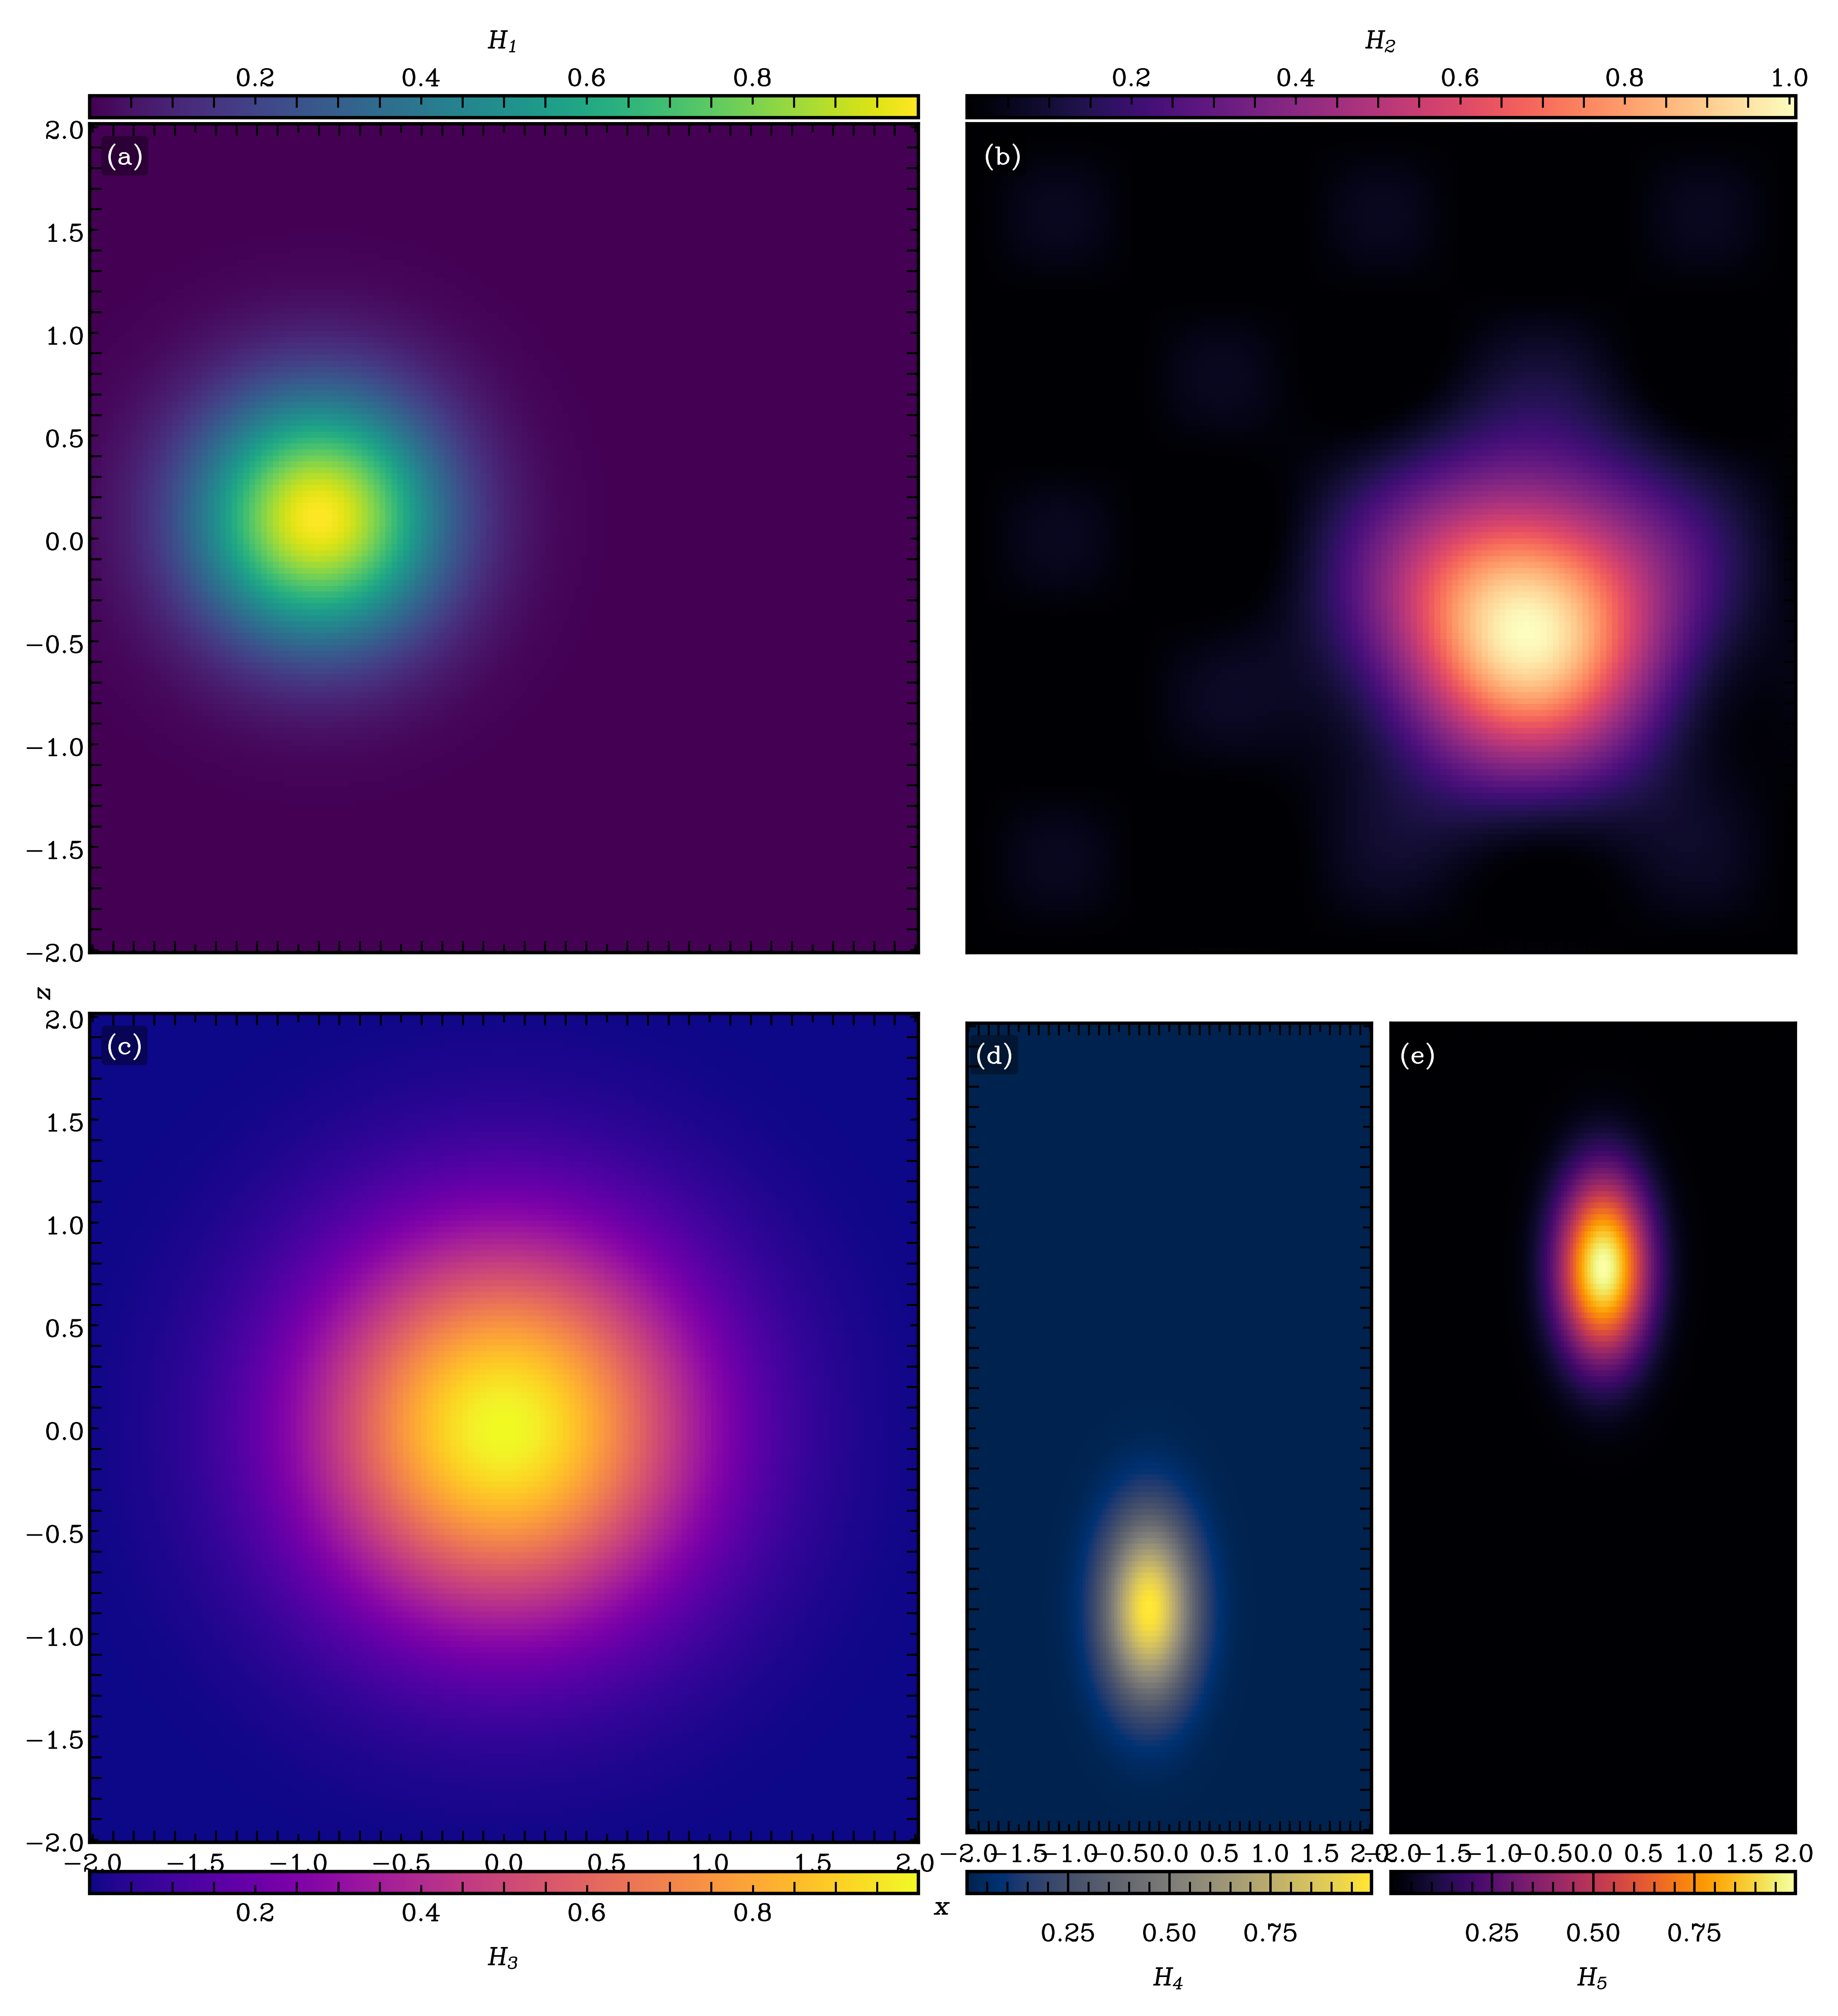

In [ ]:

# Assume your updated multi_heatmaps(...) from earlier is already defined/imported.

# --- NEW EXAMPLE DATA (5 isotropic fields) ---
nx = nz = 140
x = np.linspace(-2, 2, nx)
z = np.linspace(-2, 2, nz)
X, Z = np.meshgrid(x, z)

dens = [
    np.exp(-((X+0.9)**2 + (Z-0.1)**2) / 0.35),
    np.exp(-((X-0.7)**2 + (Z+0.4)**2) / 0.50) + 0.06*np.cos(4*X)*np.cos(4*Z),
    np.exp(-(X**2 + Z**2) / 0.85),
    np.exp(-((X+0.2)**2 + (Z+0.9)**2) / 0.20),
    np.exp(-((X-0.1)**2 + (Z-0.8)**2) / 0.20),
]
dens = [np.clip(d, 1e-9, None) for d in dens]  # keep positive if you switch on LogNorm later

fig, axes, cbs = multi_heatmaps_v2(
    dens,
    x, z,
    width_plot=7.4,
    gap_x=0.20,        # gap between left big column and right block
    gap_x_half=0.08,   # gap between the two narrow panels
    gap_y=0.25,
    per_panel_norm=True,
    use_lognorm=False,
    cmap=["viridis", "magma", "plasma", "cividis", "inferno"],
    panel_text=["(a)", "(b)", "(c)", "(d)", "(e)"],
    cbar_labels=[r"$H_1$", r"$H_2$", r"$H_3$", r"$H_4$", r"$H_5$"],
    xlabel=r"$x$",
    ylabel=r"$z$",
)

plt.show()

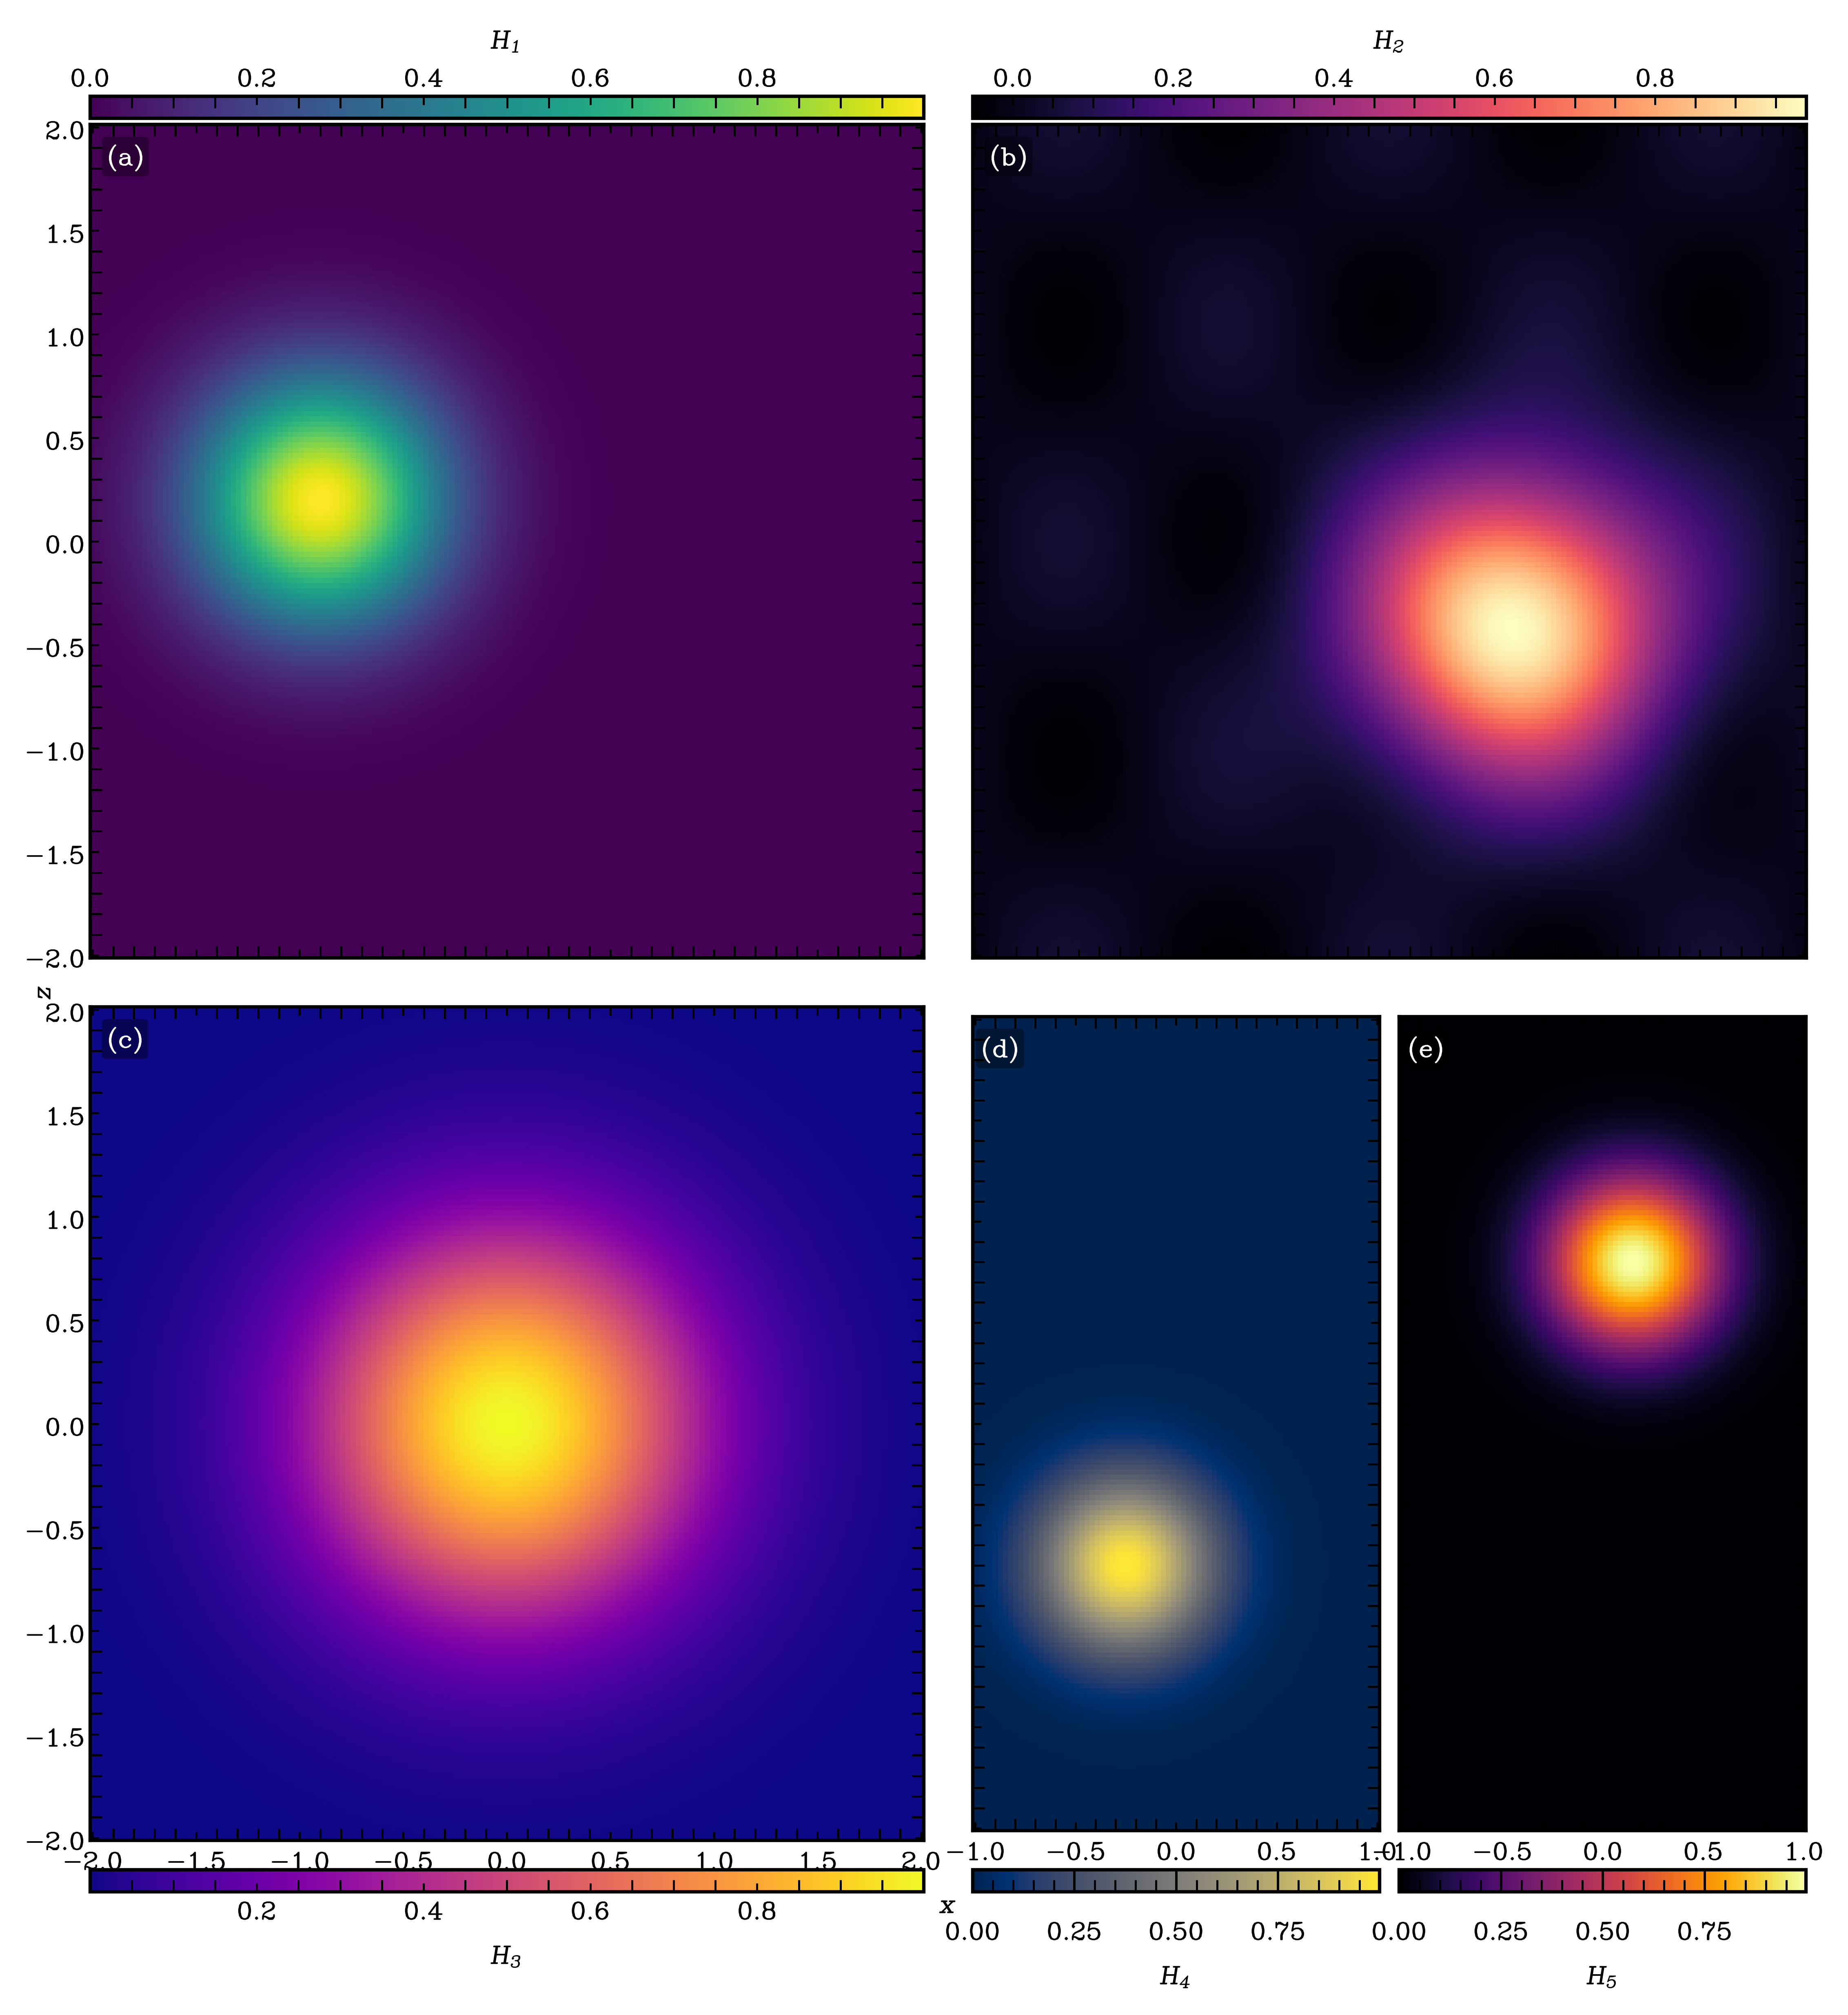

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume your updated multi_heatmaps(...) is already defined.

# Shared z-grid for all panels
nz = 160
z = np.linspace(-2, 2, nz)

# First 3 panels: full x-range [-2, 2]
nx_big = 160
x_big = np.linspace(-2, 2, nx_big)
Xb, Zb = np.meshgrid(x_big, z)

# Last 2 panels: narrower x-range [-1, 1]
nx_small = 80
x_small = np.linspace(-1, 1, nx_small)
Xs, Zs = np.meshgrid(x_small, z)

# Data for first 3 (square-domain panels)
d1 = np.exp(-((Xb + 0.9)**2 + (Zb - 0.2)**2) / 0.35)
d2 = np.exp(-((Xb - 0.6)**2 + (Zb + 0.4)**2) / 0.50) + 0.05*np.cos(4*Xb)*np.cos(3*Zb)
d3 = np.exp(-(Xb**2 + Zb**2) / 0.85)

# Data for last 2 (narrow-x panels, same z-height)
d4 = np.exp(-((Xs + 0.25)**2 + (Zs + 0.7)**2) / 0.18)
d5 = np.exp(-((Xs - 0.15)**2 + (Zs - 0.8)**2) / 0.18)

dens = [d1, d2, d3, d4, d5]

# Per-panel coordinates:
coordx = [x_big, x_big, x_big, x_small, x_small]
coordz = [z,     z,     z,     z,       z]

fig, axes, cbs = multi_heatmaps_v2(
    dens,
    coordx,
    coordz,
    width_plot=7.4,
    gap_x=0.20,
    gap_x_half=0.08,
    gap_y=0.2,
    per_panel_norm=True,
    use_lognorm=False,
    cmap=["viridis", "magma", "plasma", "cividis", "inferno"],
    panel_text=["(a)", "(b)", "(c)", "(d)", "(e)"],
    cbar_labels=[r"$H_1$", r"$H_2$", r"$H_3$", r"$H_4$", r"$H_5$"],
    xlabel=r"$x$",
    ylabel=r"$z$",
)

plt.show()

In [ ]:
run_name = ''
folder = 'DVSI/'
direc = f'/Volumes/staff-umbrella/datajmatthijsse/phd_project2/raw_data/{folder+run_name}/fargo3d/'
# direc = f'/Users/jmatthijsse/Documents/PhD_project2/fargo3d/outputs/{run_name}/'
savedir1 = f'/Users/jmatthijsse/Documents/PhD_project2/saved_plots/{folder}'
savedir = f'/Users/jmatthijsse/Documents/PhD_project2/saved_plots/{folder+run_name}'
df = pd.read_csv(f'/Volumes/staff-umbrella/datajmatthijsse/phd_project2/raw_data/{folder+run_name}/fargo3d/setups/{run_name}/initial.csv')
# df = pd.read_csv('/Users/jmatthijsse/Documents/PhD_project2/fargo3d/setups/'+run_name+'/initial.csv')
t0 = [df['rho_g'][3:-3],df['vx_g'][3:-3], df['vy_g'][3:-3], df['vz_g'][3:-3]]

frame=0
dir = direc
# read in the data from the directories
coord = vt.Coordinates(dir)
pf = vt.PolyFluid(dir)
dt = vt.time_stamps(dir, 2)[1]
t = dt*frame
frames = vt.time_stamps(dir, vt.max_save(dir))

t0n = []
for i in range(4):
    if not isinstance(v[i], (np.ndarray)):
        t0n.append(v[i]*np.ones_like(coord.z))
    else:
        t0n.append(v[i])
t0 = np.array(t0n)

# Get Stokes numbers, dust densities and equilibrium velocities
zmin = 1.5
domain = (coord.z > -zmin) & (coord.z < zmin)
coordx = coord.x
coordz = coord.z[domain]
meshX, meshZ = np.meshgrid(coordx, coordz, sparse=False, indexing='xy')
keplershear = 1.5*meshX
fluid = 0 
pf.read(frame)
rho = pf.Fluids[fluid].dens[domain,0,:]-t0[0][domain,None]
velx= pf.Fluids[fluid].velx[domain,0,:]-t0[1][domain,None]
vely = pf.Fluids[fluid].vely[domain,0,:]+keplershear-t0[2][domain,None]
velz = pf.Fluids[fluid].velz[domain,0,:]-t0[3][domain,None]
dens = [rho, velx, vely, velz]

fig, axes, cbs = pltpaper.multi_heatmaps(
    dens, coordx, coordz,
    width_plot=width_plot_l*2/3,
    cbar_mode='first_individual_rest_shared',
    use_lognorm=False,
    symmetric=True,
    cbar_labels=[r"$\rho-\rho^0$", r"$v-v^0 \, [c_\mathrm{s}]$"],
    cmap=["viridis", "seismic"],
    xlabel=r"$x \, [H_\mathrm{g}]$",
    ylabel=r"$z \, [H_\mathrm{g}]$",
    
    x_tick_step=0.25,
    y_tick_step=0.25,
    x_tick_fmt="%.2f",
    y_tick_fmt="%.2f",

    vmin = [-maxdens, -maxv],
    vmax = [maxdens, maxv],

    panel_text=[r"$\rho_\mathrm{g}$", r"$v_x$", r"$v_y$", r"$v_z$"],  # <-- top-left text
    panel_text_kwargs = dict(
        color="black",
        ha="left",
        va="top",
        transform=None,  # set per-axes below
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.35, linewidth=0.0),
    ),

    gap_x=0.4,
    gap_y=0.25,
    left=1., right=0.06,
    bottom=0.75, top=1.,
    cbar_h=0.1,              # thin
    xlabel_clearance=1.,
    cbar_pad_top=0.075,    # increase if you have a long xlabel
    cbar_pad_bottom=0.25,     # increase if x tick labels are large/rotated

    omegat = r'$\Omega t = {:.1f}$'.format(frame*dt)
)
# fig.text(r"$\Omega t=500$", fontsize=12)
# fig.savefig(savedir+'/'+l_folders[0]+'/frame_{:03d}.png'.format(frame), format='png', dpi=300)

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/staff-umbrella/datajmatthijsse/phd_project2/raw_data/DVSI//fargo3d/setups//initial.csv'

In [ ]:
stoke_range = [1e-1]#[1e-3,1e-1]
pdust = Polydust(n_dust=1,
              stokes_range=stoke_range,
              dust_density=0.01,
              gas_density=1,
              alpha_viscosity_gas=0,
              size_distribution=[1.0],#SizeDistribution(stokes_range)
              height_box=hg,
              gauss_legendre=True,
              discrete_equilibrium=False,
              pressure_gradient=True)